In [2]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD

os.chdir("/mnt/data/ProjetMeteo/Analyse_Meteo")
Path.cwd()

raw_french_temp_array = np.load("month_mean_serie.npy")

In [3]:
import pandas as pd

# ==============================================================================
# 1. PARSE THE RAW TEXT FILES
# ==============================================================================
# sep='\s+' instructs pandas to treat any amount of consecutive whitespace as a single delimiter.
# na_values=[-99.9, -99.90] captures the standard NOAA missing data flags.

# Load North Atlantic Oscillation
df_nao = pd.read_csv("demo_france/NAO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

# Load East Atlantic Pattern
df_ea = pd.read_csv("demo_france/EA.txt", sep='\s+', na_values=[-99.9, -99.90])

# ==============================================================================
# 2. STANDARDIZE THE COLUMNS
# ==============================================================================
# Ensure the columns are strictly named for accurate merging
df_nao.columns = ['Year', 'Month', 'NAO']
df_ea.columns = ['Year', 'Month', 'EA']

# ==============================================================================
# 3. MERGE INTO THE MASTER CLIMATE MATRIX
# ==============================================================================
# We perform an 'inner' merge on the Year and Month columns. 
# This strictly enforces temporal alignment. If a month is missing in one file, 
# it drops the row to prevent out-of-phase signal corruption.
df_climate = pd.merge(df_nao, df_ea, on=['Year', 'Month'], how='inner')

# ==============================================================================
# 4. BUILD THE CHRONOLOGICAL TIME INDEX
# ==============================================================================
# Convert the discrete Year and Month integer columns into a continuous DateTime object.
# We assign '01' as the day for every month to satisfy the DateTime requirement.
df_climate['Date'] = pd.to_datetime(
    df_climate['Year'].astype(str) + '-' + df_climate['Month'].astype(str) + '-01'
)

# Set the continuous Date vector as the strict mathematical index of the DataFrame
df_climate.set_index('Date', inplace=True)

# Drop the now redundant discrete temporal columns
df_climate.drop(columns=['Year', 'Month'], inplace=True)

# ==============================================================================
# 5. VERIFY MATRIX INTEGRITY
# ==============================================================================
print(df_climate.info())
print("\nFirst 5 rows:")
print(df_climate.head())

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_340161/45244839.py:10: SyntaxWarning: invalid escape sequence '\s'
  df_nao = pd.read_csv("demo_france/NAO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_340161/45244839.py:13: SyntaxWarning: invalid escape sequence '\s'
  df_ea = pd.read_csv("demo_france/EA.txt", sep='\s+', na_values=[-99.9, -99.90])


<class 'pandas.DataFrame'>
DatetimeIndex: 915 entries, 1950-01-01 to 2026-03-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NAO     915 non-null    float64
 1   EA      915 non-null    float64
dtypes: float64(2)
memory usage: 21.4 KB
None

First 5 rows:
             NAO    EA
Date                  
1950-01-01  0.92 -2.71
1950-02-01  0.40  0.66
1950-03-01 -0.36  0.82
1950-04-01  0.73  0.28
1950-05-01 -0.59 -0.51


In [4]:
df_climate = df_climate[:912]
df_climate['raw'] = raw_french_temp_array
#df_climate['cycle'] = cycle_array

In [5]:
df_sca = pd.read_csv("demo_france/SCA.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

# Load East Atlantic Pattern
df_amo = pd.read_csv("demo_france/AMO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_340161/1385202438.py:1: SyntaxWarning: invalid escape sequence '\s'
  df_sca = pd.read_csv("demo_france/SCA.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_340161/1385202438.py:4: SyntaxWarning: invalid escape sequence '\s'
  df_amo = pd.read_csv("demo_france/AMO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)


In [ ]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. DYNAMIC COLUMN MAPPING
# ==============================================================================
# Reset the index to ensure no data is hidden in the index structure
df_raw = df_sca
df_raw = df_raw.reset_index(drop=True)

# Dynamically assess the shape of the imported matrix
num_cols = df_raw.shape[1]

if num_cols == 14:
    # Condition A: The arbitrary index (0, 1, 2) was parsed as a data column
    df_raw.columns = ['Drop_Index', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw.drop(columns=['Drop_Index'])
elif num_cols == 13:
    # Condition B: The data parsed strictly as Year + 12 Months
    df_raw.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw.copy()
else:
    raise ValueError(f"Matrix Dimension Error: Expected 13 or 14 columns, but detected {num_cols}.")

# ==============================================================================
# 2. CLEANING THE DATA MATRIX
# ==============================================================================
# Remove the faulty row and replace placeholders
# We force 'Year' to numeric first to ensure strict equality checking
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
df_clean = df_clean.dropna(subset=['Year']) # Drop if the header row was imported as data
df_clean = df_clean[df_clean['Year'] != -9999]
df_clean = df_clean.replace(-9999.00, np.nan)

# ==============================================================================
# 3. STRUCTURAL TRANSFORMATION (WIDE TO LONG)
# ==============================================================================
# Melt the dataframe: Year remains the identifier, months become a variable column
df_long = df_clean.melt(id_vars=['Year'], var_name='Month', value_name='Target_Value')

# Map string months to integers for datetime conversion
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_long['Month_Num'] = df_long['Month'].map(month_map)

# ==============================================================================
# 4. TIME SERIES INDEXING
# ==============================================================================
# Construct standard Datetime objects (YYYY-MM-01)
# Ensure Year is strictly an integer string for the datetime parser
df_long['Date'] = pd.to_datetime(
    df_long['Year'].astype(int).astype(str) + '-' + 
    df_long['Month_Num'].astype(str) + '-01'
)

# Sort chronologically
df_ts = df_long.sort_values('Date')

# Set the Date as the index and isolate the single dimension
df_1d = df_ts.set_index('Date')[['Target_Value']]

# Drop the future unrecorded months
df_final = df_1d.dropna()


            Target_Value
Date                    
1950-01-01          0.78
1950-02-01         -0.94
1950-03-01         -0.22
1950-04-01          0.46
1950-05-01          0.28


In [ ]:
df_climate = df_climate[:905]
df_climate['AMO'] = df_amo[2][:905].values
df_climate['SCA'] = df_final.values
df_climate

In [58]:
from PyEMD import CEEMDAN
from scipy.fft import fft, fftfreq

def compute_dominant_period(time_series, sampling_interval=1.0):
    """
    Computes the dominant period of a discrete time series using the Fast Fourier Transform (FFT).
    
    Parameters:
    time_series (ndarray): The 1D input array (e.g., an isolated IMF).
    sampling_interval (float): The time between samples (default 1.0 month).
    
    Returns:
    float: The dominant period in the same units as the sampling interval.
    """
    N = len(time_series)
    # Subtract mean to remove the zero-frequency (DC) component
    yf = fft(time_series - np.mean(time_series))
    xf = fftfreq(N, d=sampling_interval)
    
    # Isolate positive frequencies (Nyquist limit)
    positive_freq_indices = np.where(xf > 0)
    frequencies = xf[positive_freq_indices]
    power_spectrum = np.abs(yf[positive_freq_indices])**2
    
    if len(power_spectrum) == 0:
        return np.inf
        
    # Extract the period of maximum spectral power
    peak_idx = np.argmax(power_spectrum)
    dominant_freq = frequencies[peak_idx]
    
    return 1.0 / dominant_freq if dominant_freq > 0 else np.inf

def extract_ceemdan_cycle_fft(time_series, min_period_months, max_period_months, trials=100, epsilon=0.2):
    """
    Executes CEEMDAN and reconstructs the signal autonomously by selecting IMFs 
    whose dominant FFT periods fall strictly within the defined target band.
    
    Parameters:
    time_series (ndarray or Series): The raw 1D input data.
    min_period_months (float): The minimum acceptable period (e.g., 60 for 5 years).
    max_period_months (float): The maximum acceptable period (e.g., 240 for 20 years).
    trials (int): Ensemble size.
    epsilon (float): Standard deviation of added noise relative to the signal.
    
    Returns:
    ndarray: The reconstructed time series.
    ndarray: The full matrix of all extracted IMFs.
    list: The integer indices of the dynamically retained IMFs.
    """
    s = np.array(time_series)
    ceemdan = CEEMDAN()
    ceemdan.trials = trials
    ceemdan.epsilon = epsilon * np.std(s)
    
    print(f"Executing CEEMDAN... (Length: {len(s)})")
    all_imfs = ceemdan(s)
    
    reconstructed_cycle = np.zeros(len(s))
    num_imfs = all_imfs.shape[0] - 1  # Exclude the residual (last row)
    retained_indices = []
    
    for i in range(num_imfs):
        period = compute_dominant_period(all_imfs[i])
        
        # Evaluate against the defined physical bandpass bounds
        if min_period_months <= period <= max_period_months:
            reconstructed_cycle += all_imfs[i]
            retained_indices.append(i)
            print(f"  -> Retaining IMF {i} (Dominant Period: {period:.2f} months)")
        else:
            print(f"  -> Discarding IMF {i} (Dominant Period: {period:.2f} months)")
            
    return reconstructed_cycle, all_imfs, retained_indices

# ==============================================================================
# EXECUTION AND RECONSTRUCTION
# ==============================================================================
# Define the target physical band in months. 
# Example: > 5 years (60 months) and < 30 years (360 months) to isolate decadal cycles
target_min_months = 120.0
target_max_months = 960.0

print("Processing Atlantic Multidecadal Oscillation (AMO)...")
amo_cycle, amo_all_imfs, amo_kept = extract_ceemdan_cycle_fft(df_climate['AMO'], target_min_months, target_max_months)

print("\nProcessing Target Temperature (Y)...")
y_cycle, y_all_imfs, y_kept = extract_ceemdan_cycle_fft(df_climate['raw'], target_min_months, target_max_months)

print("\nProcessing North Atlantic Oscillation (NAO)...")
nao_cycle, nao_all_imfs, nao_kept = extract_ceemdan_cycle_fft(df_climate['NAO'], target_min_months, target_max_months)

print("\nProcessing East Atlantic Pattern (EA)...")
ea_cycle, ea_all_imfs, ea_kept = extract_ceemdan_cycle_fft(df_climate['EA'], target_min_months, target_max_months)

print("\nProcessing Scandinavian Blocking (SCA)...")
sca_cycle, sca_all_imfs, sca_kept = extract_ceemdan_cycle_fft(df_climate['SCA'], target_min_months, target_max_months)

# ==============================================================================
# REBUILDING THE GAM FEATURE MATRIX
# ==============================================================================
# Insert the non-stationary, low-frequency cycles back into a new DataFrame
df_gam_filtered = pd.DataFrame({
    'Temp_Cycle': y_cycle,
    'NAO_Cycle': nao_cycle,
    'EA_Cycle': ea_cycle,
    'SCA_Cycle': sca_cycle,
    'AMO_Cycle': amo_cycle,
    # The secular trend is strictly the final row of the target temperature matrix
    'Global_Warming': y_all_imfs[-1] - np.mean(y_all_imfs[-1])
})

X_ceemdan = df_gam_filtered[['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle']].values
y_ceemdan = df_gam_filtered['Temp_Cycle'].values

print("\nCEEMDAN Data Engineering Complete. Ready for GAM Tensor Integration.")

Processing Atlantic Multidecadal Oscillation (AMO)...
Executing CEEMDAN... (Length: 905)
  -> Discarding IMF 0 (Dominant Period: 4.48 months)
  -> Discarding IMF 1 (Dominant Period: 11.91 months)
  -> Discarding IMF 2 (Dominant Period: 43.10 months)
  -> Discarding IMF 3 (Dominant Period: 43.10 months)
  -> Discarding IMF 4 (Dominant Period: 113.12 months)
  -> Retaining IMF 5 (Dominant Period: 226.25 months)

Processing Target Temperature (Y)...
Executing CEEMDAN... (Length: 905)
  -> Discarding IMF 0 (Dominant Period: 2.26 months)
  -> Discarding IMF 1 (Dominant Period: 12.07 months)
  -> Discarding IMF 2 (Dominant Period: 12.07 months)
  -> Discarding IMF 3 (Dominant Period: 28.28 months)
  -> Discarding IMF 4 (Dominant Period: 90.50 months)
  -> Retaining IMF 5 (Dominant Period: 181.00 months)
  -> Retaining IMF 6 (Dominant Period: 452.50 months)

Processing North Atlantic Oscillation (NAO)...
Executing CEEMDAN... (Length: 905)
  -> Discarding IMF 0 (Dominant Period: 2.49 months)
 

Rendering Spectral Matrix: Target Global Temperature
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


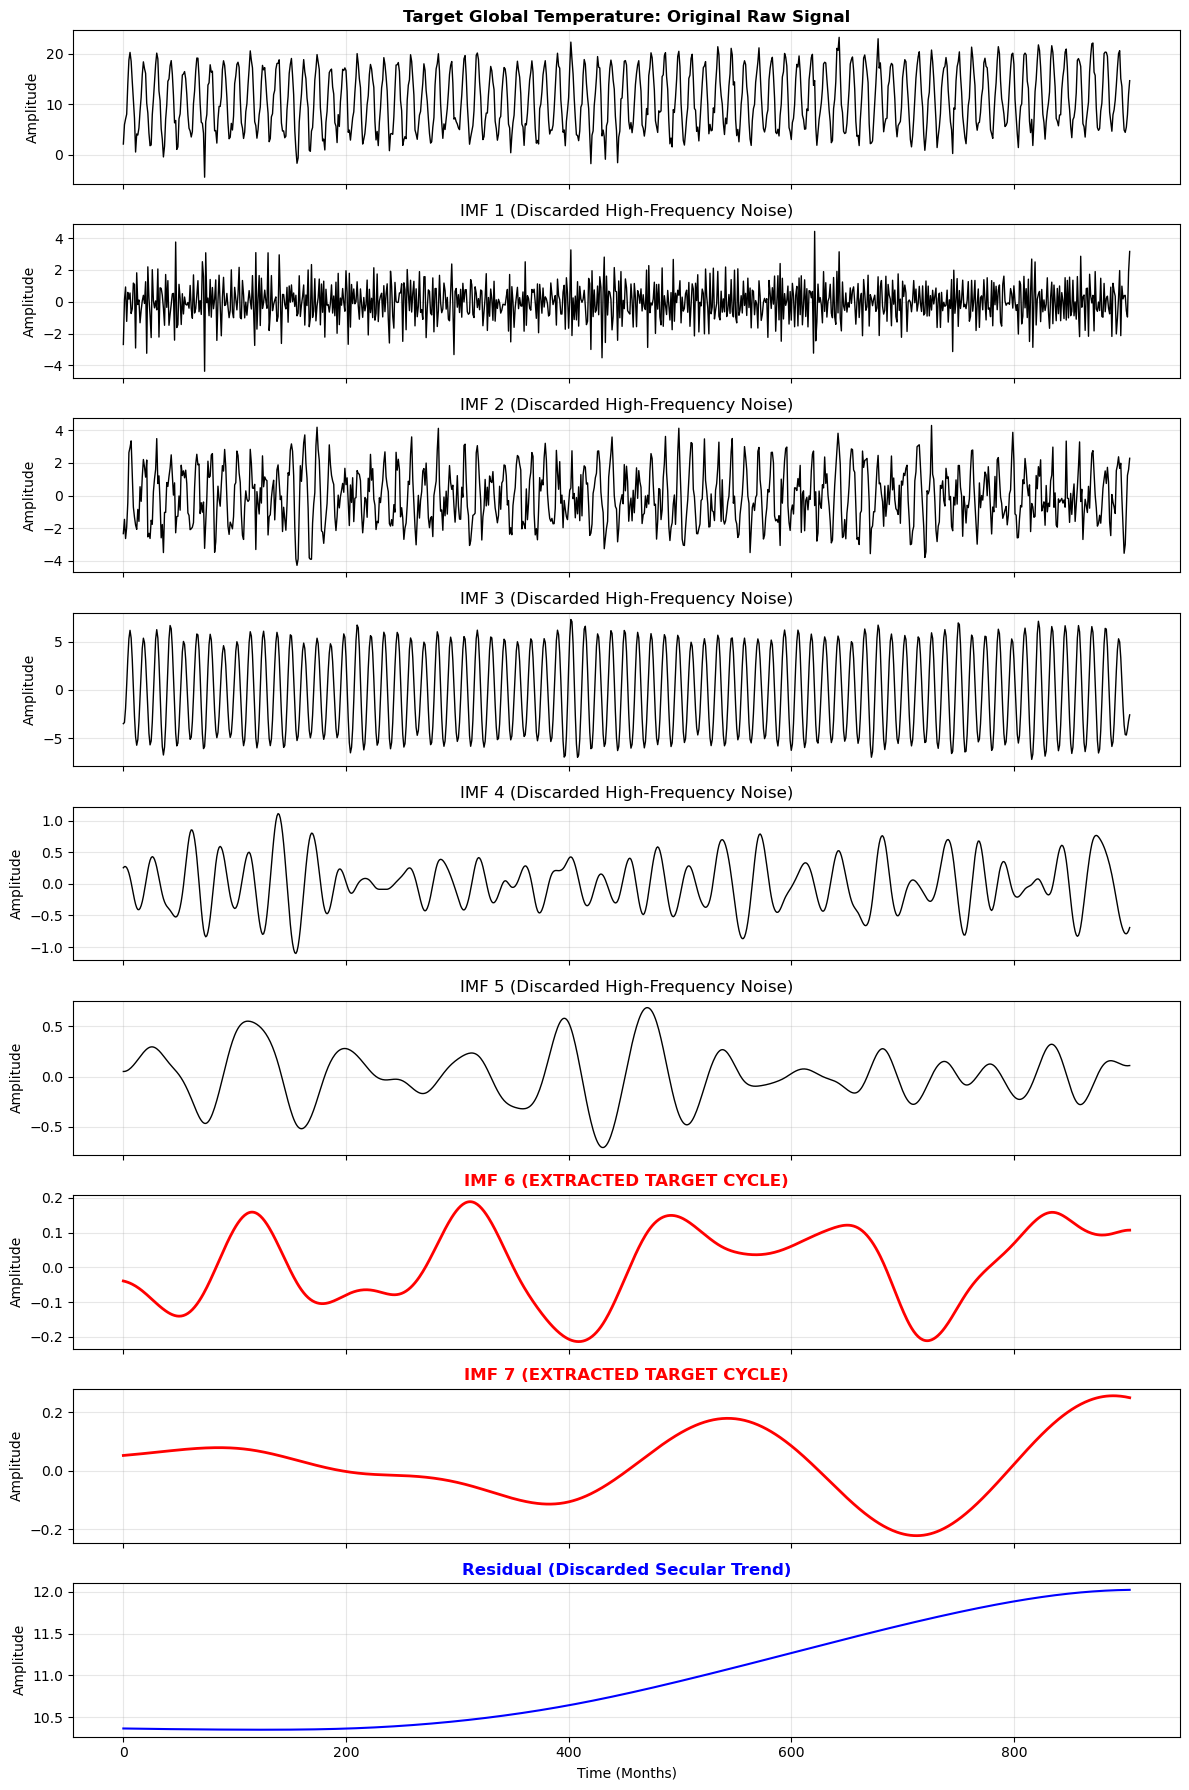

Rendering Spectral Matrix: North Atlantic Oscillation (NAO)
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


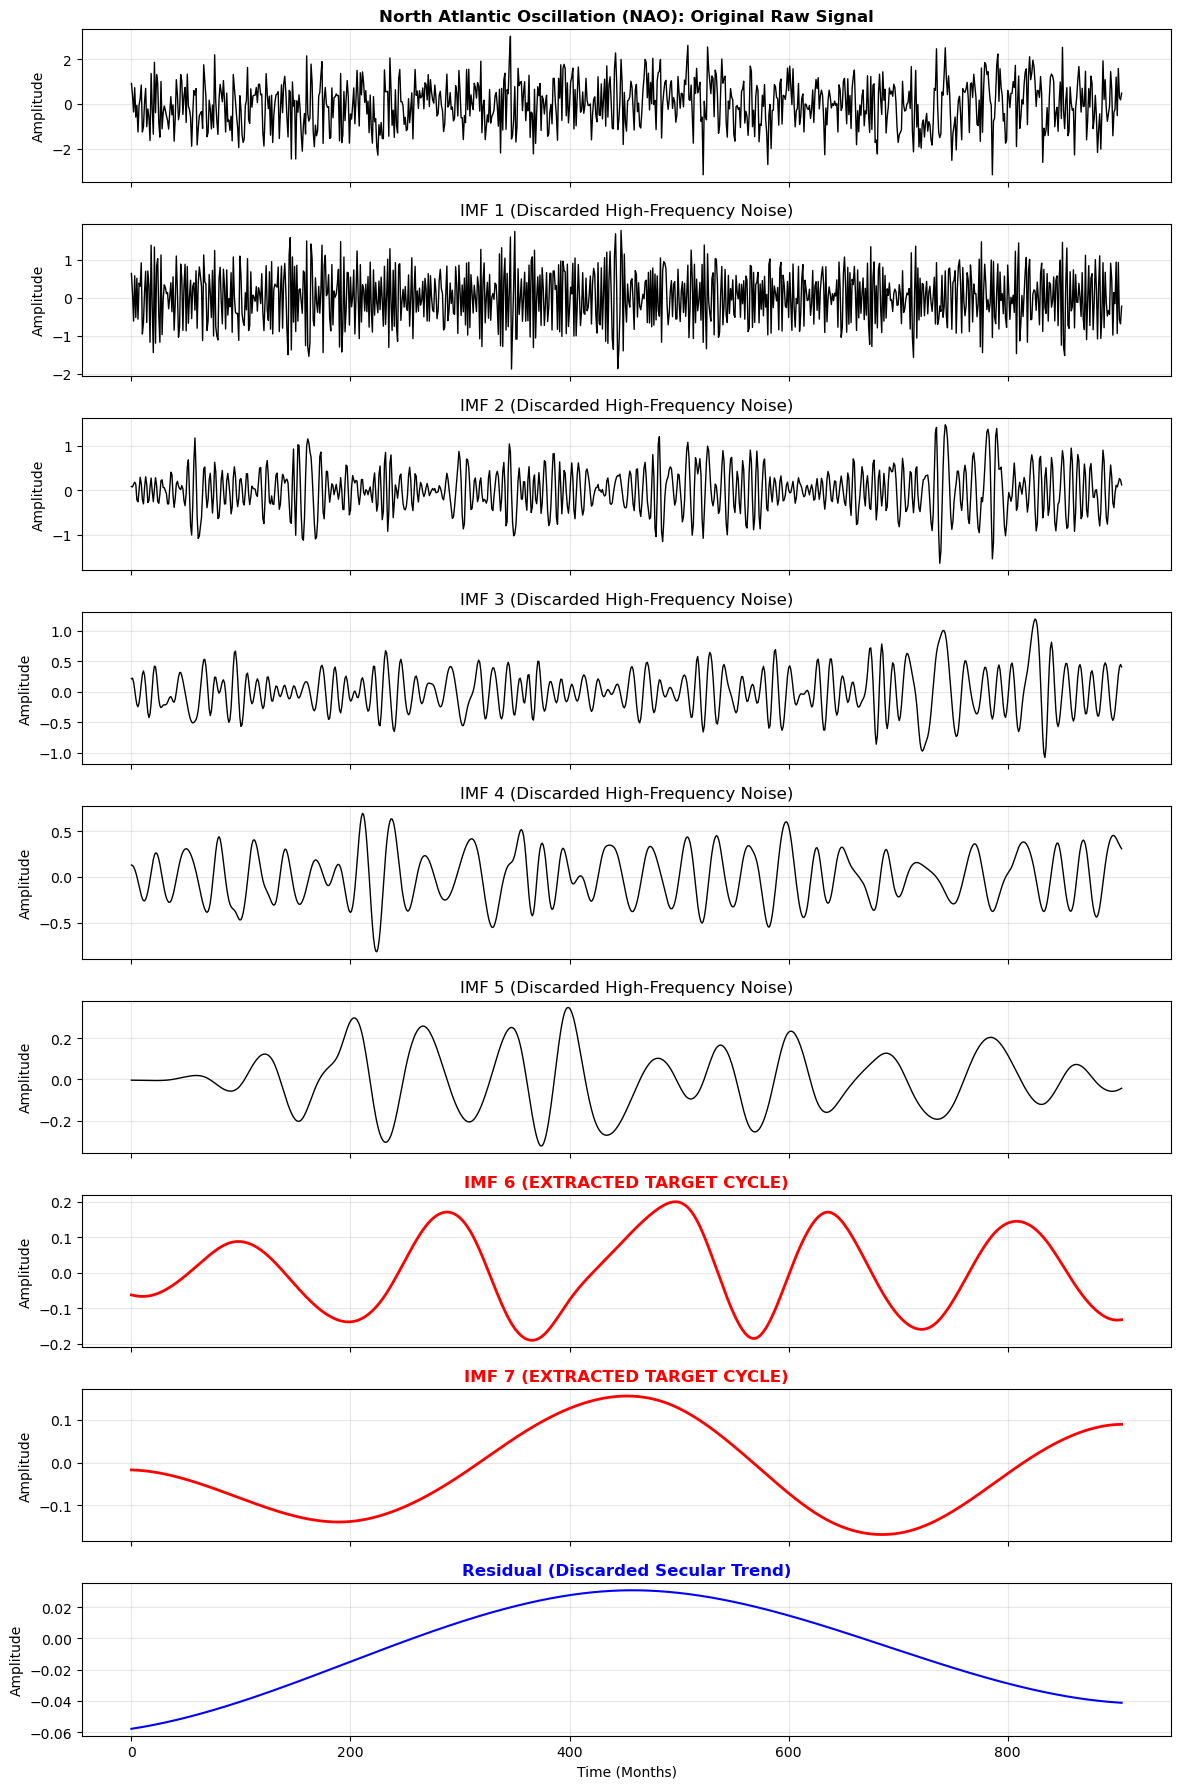

Rendering Spectral Matrix: East Atlantic Pattern (EA)
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


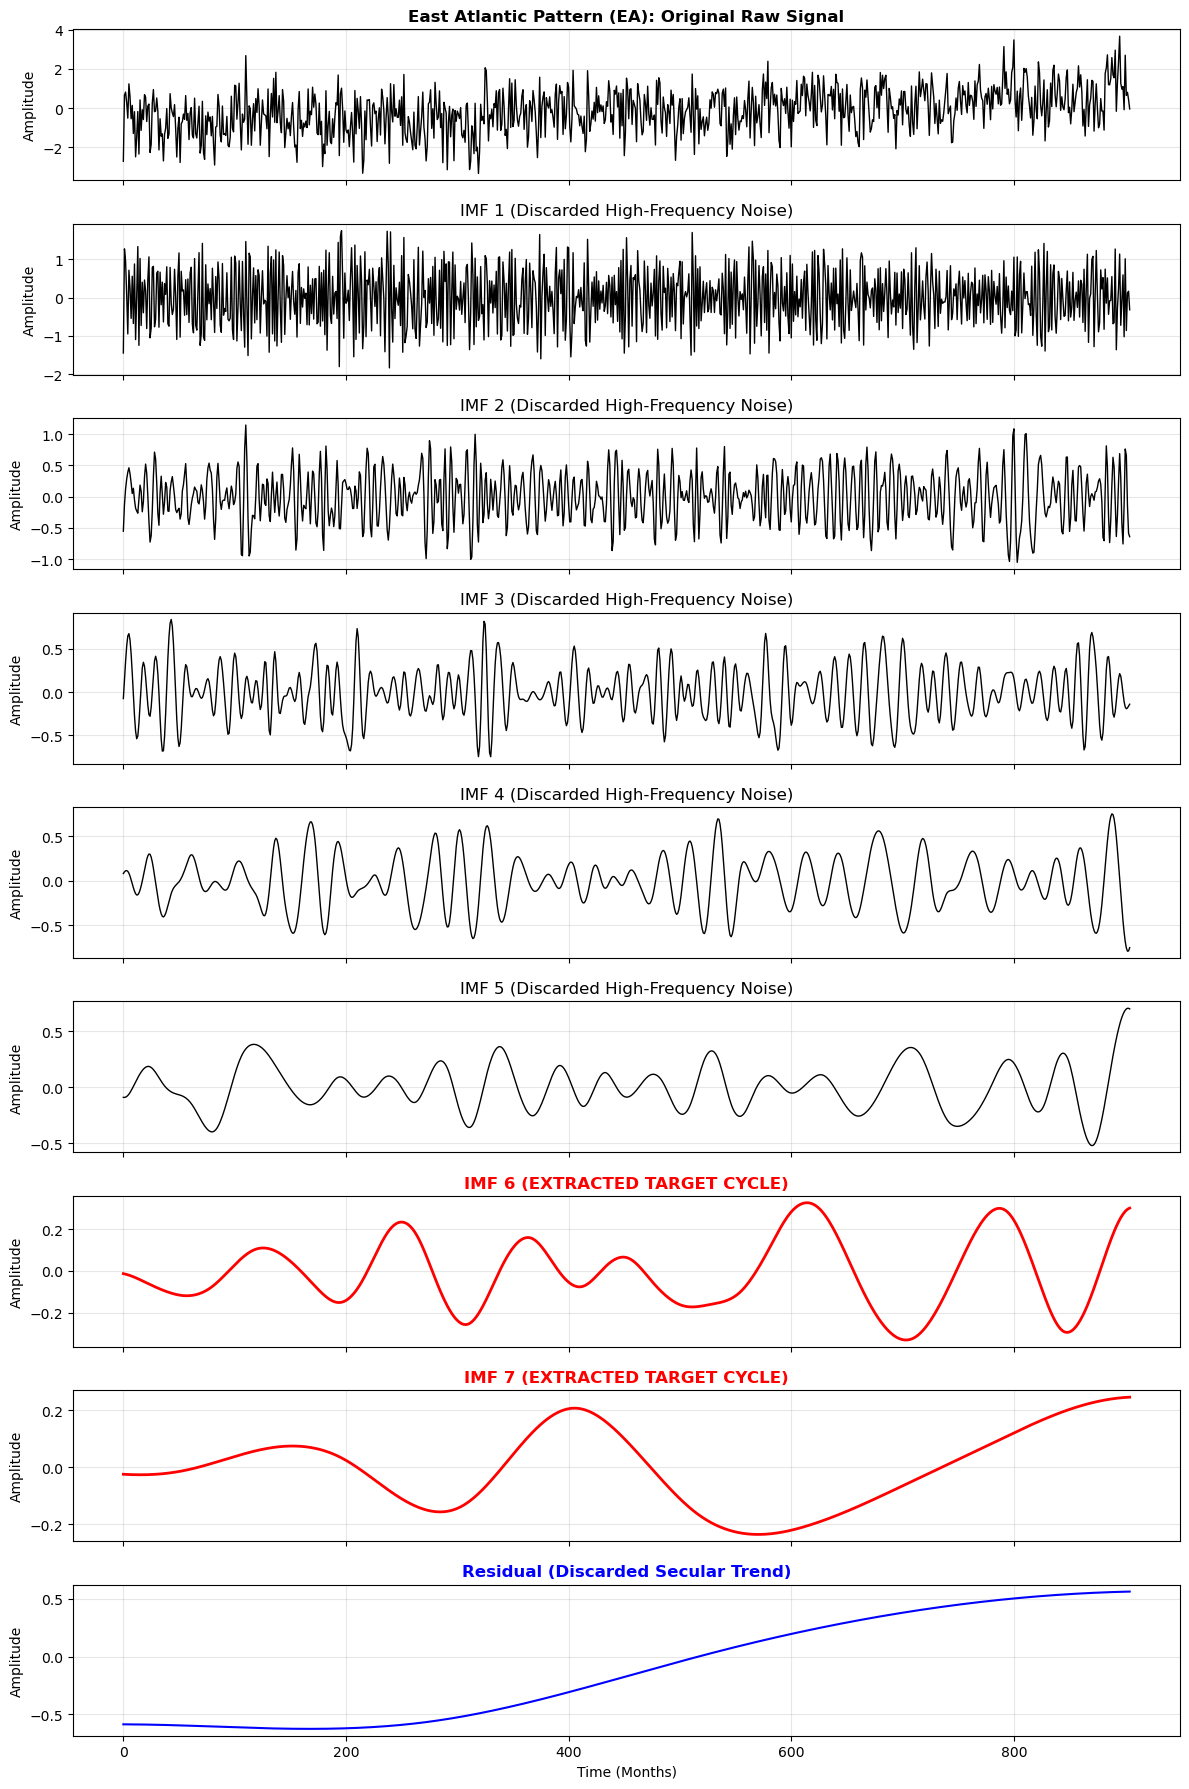

Rendering Spectral Matrix: Scandinavian Blocking (SCA)
Mathematical Modes Extracted for Cyclic Tensor: [5, 6]


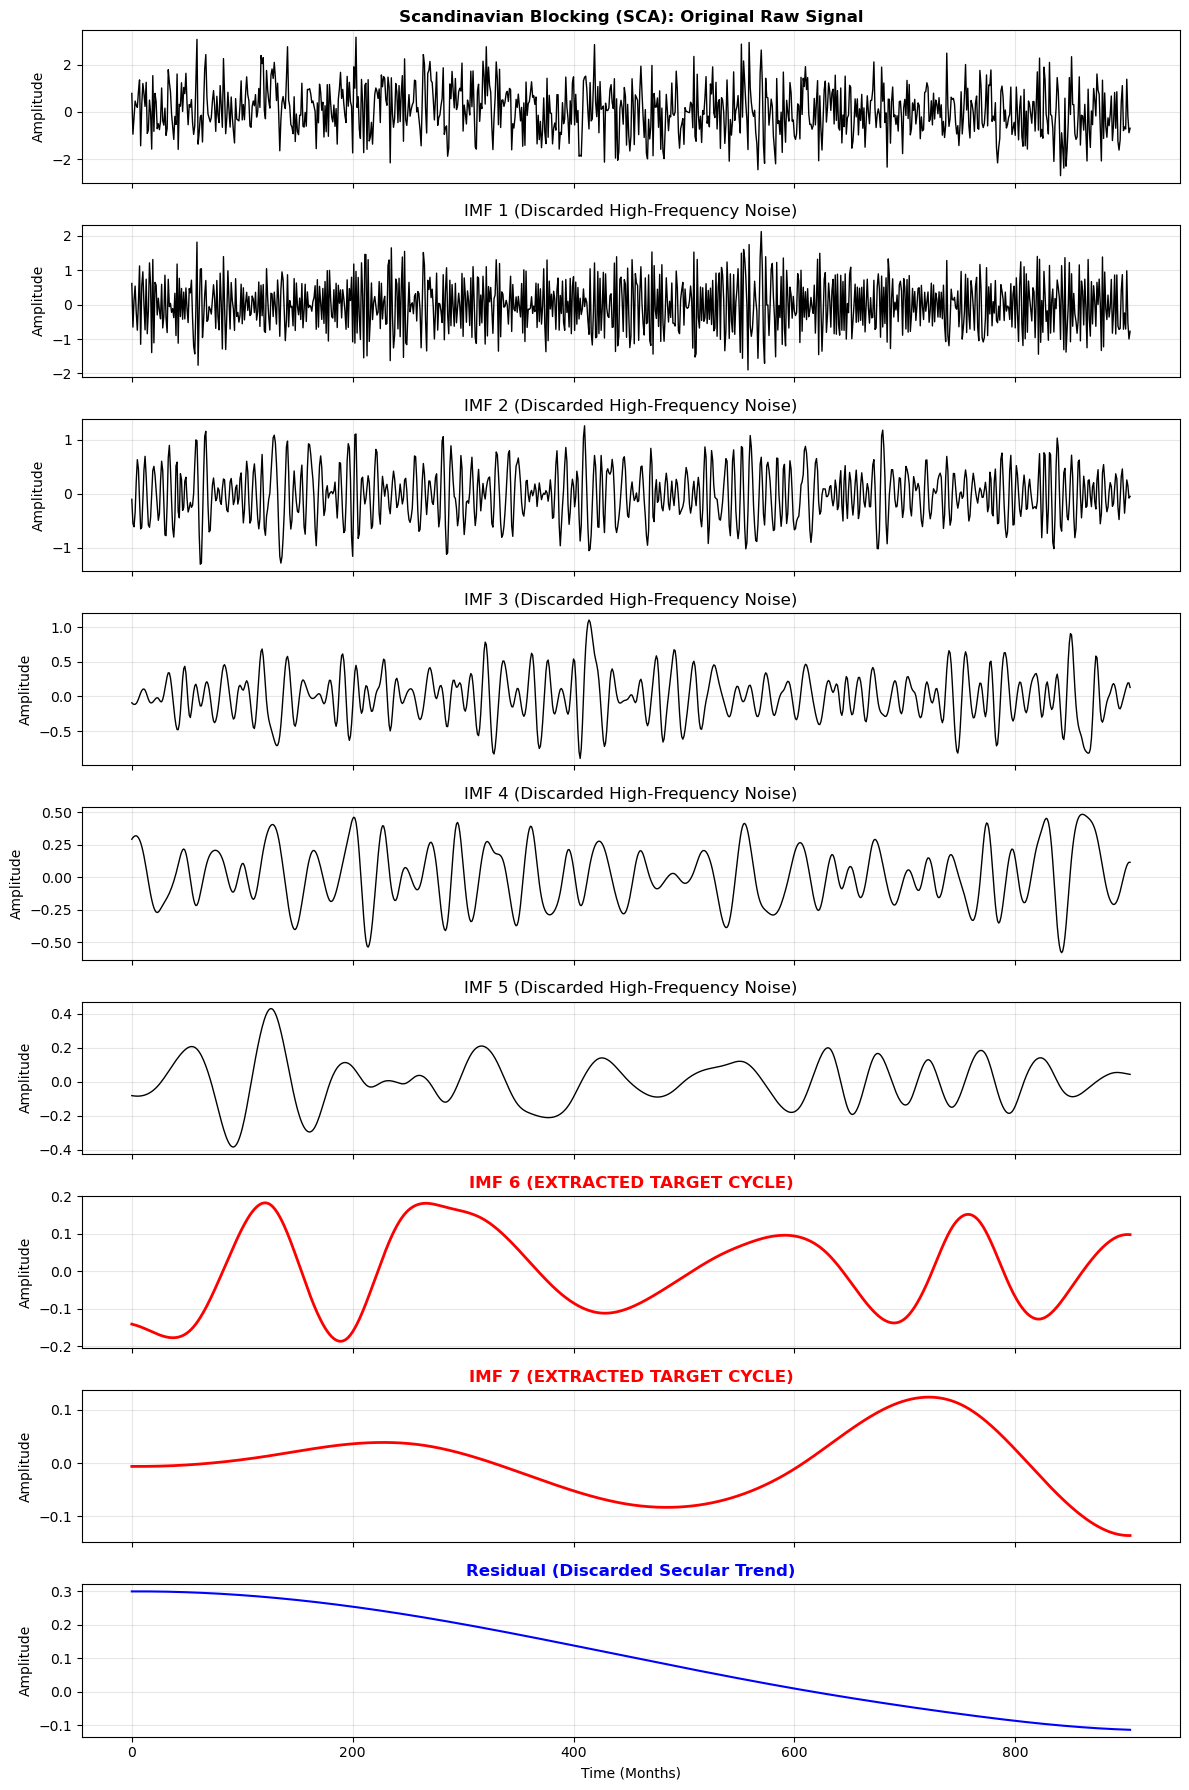

Rendering Spectral Matrix: Atlantic Multidecadal Oscillation (AMO)
Mathematical Modes Extracted for Cyclic Tensor: [5]


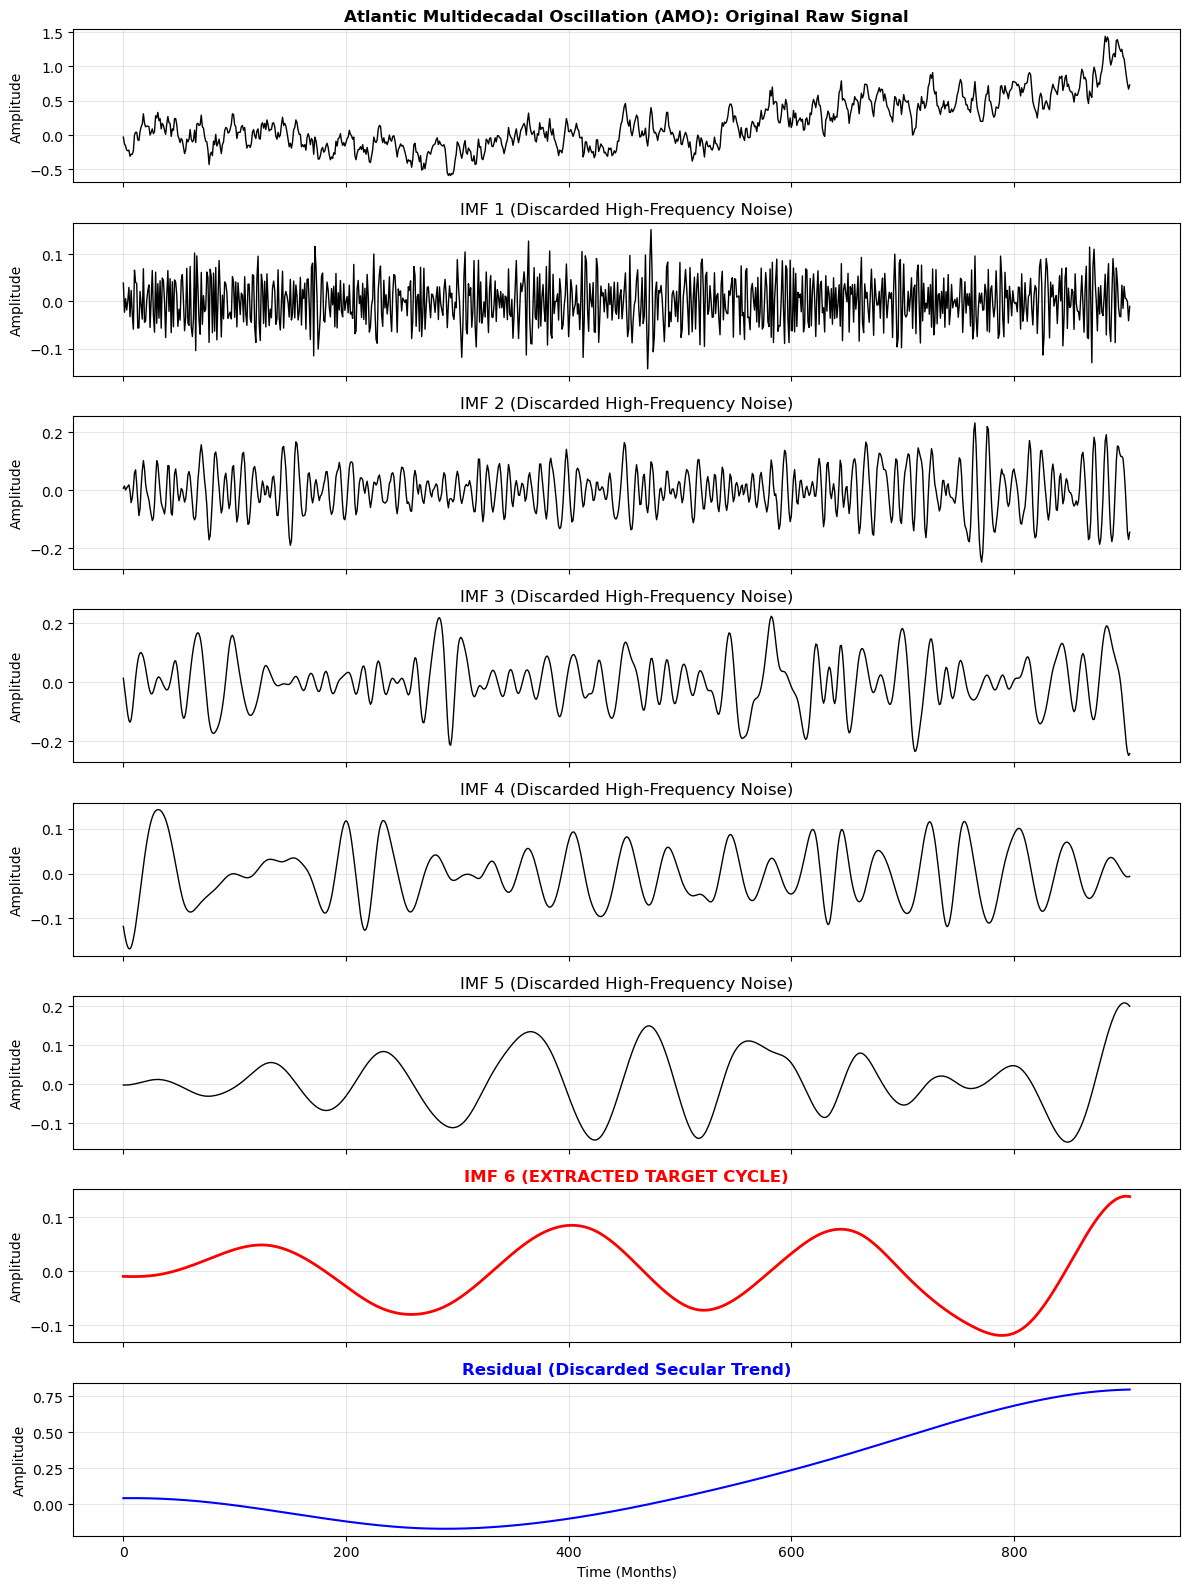

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ceemdan_decomposition(original_series, all_imfs, extracted_indices, title_prefix="Variable"):
    """
    Plots the full CEEMDAN decomposition matrix, highlighting the specific 
    low-frequency IMFs that were extracted to build the cyclic feature matrix.
    
    Parameters:
    original_series (ndarray): The raw 1D input data.
    all_imfs (ndarray): The 2D array output from PyEMD (IMFs + Residual).
    extracted_indices (list): The Python indices (0-based) of the targeted IMFs.
    title_prefix (str): Label for the specific variable being plotted.
    """
    # The last row of the matrix is strictly the residual, not an IMF
    num_imfs = all_imfs.shape[0] - 1 
    time_axis = np.arange(len(original_series))
    
    # Create a dynamic figure height based on the number of extracted modes
    fig, axes = plt.subplots(num_imfs + 2, 1, figsize=(12, 2 * (num_imfs + 2)), sharex=True)
    
    # ==============================================================================
    # 1. Plot the Original Raw Signal
    # ==============================================================================
    axes[0].plot(time_axis, original_series, color='black', linewidth=1)
    axes[0].set_title(f"{title_prefix}: Original Raw Signal", fontweight='bold')
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)
    
    # ==============================================================================
    # 2. Plot the Intrinsic Mode Functions (IMFs)
    # ==============================================================================
    for i in range(num_imfs):
        ax = axes[i + 1]
        
        # Check if this specific IMF is part of your target cyclic reconstruction
        if i in extracted_indices:
            color = 'red'
            linewidth = 2.0
            # Note: Adding 1 to 'i' maps 0-based Python indexing to standard 1-based IMF literature
            title = f"IMF {i + 1} (EXTRACTED TARGET CYCLE)" 
            ax.set_title(title, color=color, fontweight='bold')
        else:
            color = 'black'
            linewidth = 1.0
            title = f"IMF {i + 1} (Discarded High-Frequency Noise)"
            ax.set_title(title)
            
        ax.plot(time_axis, all_imfs[i], color=color, linewidth=linewidth)
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
    
    # ==============================================================================
    # 3. Plot the Non-Stationary Residual
    # ==============================================================================
    axes[-1].plot(time_axis, all_imfs[-1], color='blue', linewidth=1.5)
    axes[-1].set_title("Residual (Discarded Secular Trend)", color='blue', fontweight='bold')
    axes[-1].set_xlabel("Time (Months)")
    axes[-1].set_ylabel("Amplitude")
    axes[-1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# ==============================================================================
# EXECUTION
# ==============================================================================
# Execute this function for each of your preprocessed variables.
# For example, to plot the North Atlantic Oscillation decomposition:
execution_batch = [
    (df_climate['raw'].values, y_all_imfs, y_kept, "Target Global Temperature"),
    (df_climate['NAO'].values, nao_all_imfs, nao_kept, "North Atlantic Oscillation (NAO)"),
    (df_climate['EA'].values, ea_all_imfs, ea_kept, "East Atlantic Pattern (EA)"),
    (df_climate['SCA'].values, sca_all_imfs, sca_kept, "Scandinavian Blocking (SCA)"),
    (df_climate['AMO'].values, amo_all_imfs, amo_kept, "Atlantic Multidecadal Oscillation (AMO)")
]

# Iterate and compute visual matrices
for raw_data, imf_matrix, target_indices, var_name in execution_batch:
    print(f"Rendering Spectral Matrix: {var_name}")
    print(f"Mathematical Modes Extracted for Cyclic Tensor: {target_indices}")
    
    plot_ceemdan_decomposition(
        original_series=raw_data, 
        all_imfs=imf_matrix, 
        extracted_indices=target_indices, 
        title_prefix=var_name
    )

In [62]:
def compute_dynamic_boundaries(imf_metadata):
    """
    Dynamically computes the maximum thermodynamic lag bound for cross-correlation 
    to physically prevent mathematical wave aliasing and phase inversions.
    
    Parameters:
    imf_metadata (dict): A dictionary mapping the variable name to a list of 
                         dominant periods (in months) of its RETAINED IMFs.
                         
    Returns:
    dict: The exact integer bounds to feed into the target_lag_correlation function.
    """
    dynamic_bounds = {}
    
    print("--- COMPUTING DYNAMIC SPECTRAL BOUNDARIES ---")
    for predictor, periods in imf_metadata.items():
        # Ensure only strictly positive numerical periods are evaluated
        valid_periods = [p for p in periods if p > 0 and not np.isinf(p)]
        
        if not valid_periods:
            print(f"Warning: No valid periods for {predictor}. Defaulting to 120.")
            dynamic_bounds[predictor] = 120
            continue
            
        # Extract the fastest macroscopic wave in the retained composite
        p_crit = min(valid_periods)
        
        # Calculate strict cutoff just prior to the λ/2 phase inversion
        max_bound = int(np.floor(p_crit * 0.45))
        
        # Absolute safety overrides (Optional, based on oceanic physics)
        # Prevents micro-boundaries if a high-frequency IMF bypassed the bandpass
        if max_bound < 24: 
            max_bound = 24
            
        dynamic_bounds[predictor] = max_bound
        
        print(f"{predictor}:")
        print(f"  -> Retained Periods: {[round(p, 1) for p in valid_periods]} months")
        print(f"  -> Critical Wave (P_crit): {p_crit:.1f} months")
        print(f"  -> Inversion Threshold (λ/2): {p_crit / 2:.1f} months")
        print(f"  -> ASSIGNED LAG BOUNDARY: {max_bound} months\n")
        
    return dynamic_bounds

# ==============================================================================
# EXECUTION PIPELINE INTEGRATION
# ==============================================================================
# Input the exact dominant periods of the IMFs you retained for each variable.
# (These values are derived directly from the console output of your FFT function).

retained_imf_periods = {    
    'SCA_Cycle': [129.29, 226.25, 452.50],
    'EA_Cycle': [181.0, 452.5],
    'NAO_Cycle': [181.0], 
    'AMO_Cycle': [226.25] 
}

# 1. Compute the strict mathematical limits
calculated_physical_bounds = compute_dynamic_boundaries(retained_imf_periods)


--- COMPUTING DYNAMIC SPECTRAL BOUNDARIES ---
SCA_Cycle:
  -> Retained Periods: [129.3, 226.2, 452.5] months
  -> Critical Wave (P_crit): 129.3 months
  -> Inversion Threshold (λ/2): 64.6 months
  -> ASSIGNED LAG BOUNDARY: 58 months

EA_Cycle:
  -> Retained Periods: [181.0, 452.5] months
  -> Critical Wave (P_crit): 181.0 months
  -> Inversion Threshold (λ/2): 90.5 months
  -> ASSIGNED LAG BOUNDARY: 81 months

NAO_Cycle:
  -> Retained Periods: [181.0] months
  -> Critical Wave (P_crit): 181.0 months
  -> Inversion Threshold (λ/2): 90.5 months
  -> ASSIGNED LAG BOUNDARY: 81 months

AMO_Cycle:
  -> Retained Periods: [226.2] months
  -> Critical Wave (P_crit): 226.2 months
  -> Inversion Threshold (λ/2): 113.1 months
  -> ASSIGNED LAG BOUNDARY: 101 months



Executing Forward Causality Correlation against Temp_Cycle...

--- TARGET MULTIDECADAL LAG SUMMARY ---
Predictor     Target Extraction Window  Peak Correlation (r)  Optimal Lag (Months)                Physical Dynamic
NAO_Cycle Temp_Cycle        1 to 81 mo                0.6466                    28 Macroscopic Thermodynamic Delay
AMO_Cycle Temp_Cycle       1 to 101 mo               -0.5214                    60 Macroscopic Thermodynamic Delay
 EA_Cycle Temp_Cycle        1 to 81 mo                0.2937                    77 Macroscopic Thermodynamic Delay
SCA_Cycle Temp_Cycle        1 to 58 mo               -0.2857                    58 Macroscopic Thermodynamic Delay


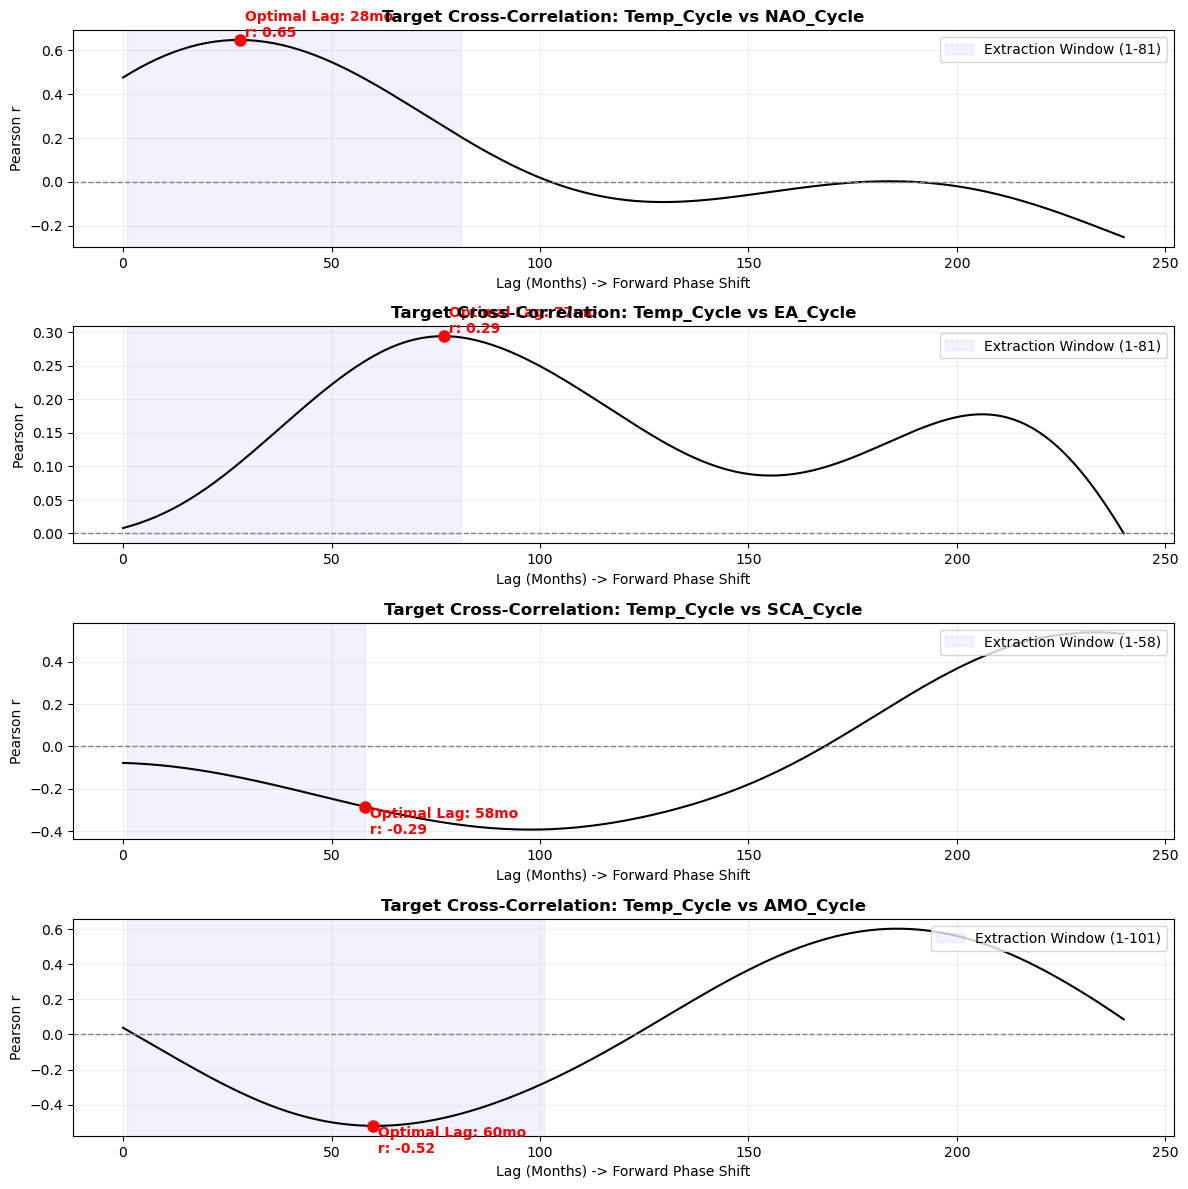

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def target_lag_correlation(df, target_var, predictors, max_lag_plot=240, search_bounds=None):
    if search_bounds is None:
        search_bounds = {p: 120 for p in predictors}

    cross_corr_data = {}
    summary_stats = []
    
    # Base array for all tested lags
    lags = np.arange(0, max_lag_plot + 1)
    
    print(f"Executing Forward Causality Correlation against {target_var}...")
    
    for predictor in predictors:
        correlations = []
        
        for lag in lags:
            shifted_predictor = df[predictor].shift(lag)
            corr = df[target_var].corr(shifted_predictor)
            correlations.append(corr)
            
        correlations = np.array(correlations)
        cross_corr_data[predictor] = correlations
        
        # ==============================================================================
        # MATHEMATICAL EXTRACTION BLOCK
        # ==============================================================================
        upper_bound = search_bounds.get(predictor, 120)
        
        # STRICT BOUNDING: Lag must be > 0 AND <= upper_bound
        valid_indices = np.where((lags <= upper_bound) & (lags > 0))[0]
        valid_lags = lags[valid_indices]
        valid_correlations = correlations[valid_indices]
        
        max_abs_idx = np.argmax(np.abs(valid_correlations))
        peak_corr = valid_correlations[max_abs_idx]
        optimal_lag = valid_lags[max_abs_idx]
            
        summary_stats.append({
            "Predictor": predictor,
            "Target": target_var,
            "Extraction Window": f"1 to {upper_bound} mo",
            "Peak Correlation (r)": round(peak_corr, 4),
            "Optimal Lag (Months)": optimal_lag,
            "Physical Dynamic": "Macroscopic Thermodynamic Delay"
        })
        
    df_summary = pd.DataFrame(summary_stats).sort_values(by="Peak Correlation (r)", key=abs, ascending=False)
    
    return df_summary, cross_corr_data, lags, search_bounds

# ==============================================================================
# EXECUTION
# ==============================================================================
target = 'Temp_Cycle'
# Excluded EA based on previous structural analysis
predictors_to_test = ['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle'] 

physical_bounds = calculated_physical_bounds


df_target_summary, target_corr_data, lag_axis, applied_bounds = target_lag_correlation(
    df=df_gam_filtered, 
    target_var=target, 
    predictors=predictors_to_test, 
    max_lag_plot=240, 
    search_bounds=physical_bounds
)

print("\n--- TARGET MULTIDECADAL LAG SUMMARY ---")
print(df_target_summary.to_string(index=False))

# ==============================================================================
# VISUALIZATION BLOCK
# ==============================================================================
num_plots = len(predictors_to_test)
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3 * num_plots))
if num_plots == 1:
    axes = [axes]

for i, (predictor, corr_array) in enumerate(target_corr_data.items()):
    ax = axes[i]
    ax.plot(lag_axis, corr_array, color='black', linewidth=1.5)
    
    bound_limit = applied_bounds.get(predictor, 120)
    
    # STRICT BOUNDING IN THE PLOT: Synchronized with the math block
    valid_indices = np.where((lag_axis <= bound_limit) & (lag_axis > 0))[0]
    valid_corrs = corr_array[valid_indices]
    
    max_idx = np.argmax(np.abs(valid_corrs))
    peak_lag = lag_axis[valid_indices][max_idx]
    peak_r = valid_corrs[max_idx]
    
    # Baselines and Bounding Area Highlight
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    # Start the blue shading strictly at 1, not 0
    ax.axvspan(1, bound_limit, color='blue', alpha=0.05, label=f'Extraction Window (1-{bound_limit})')
    
    # Highlight Valid Peak
    ax.plot(peak_lag, peak_r, 'ro', markersize=8)
    ax.text(peak_lag, peak_r, f' Optimal Lag: {peak_lag}mo\n r: {peak_r:.2f}', 
             color='red', fontweight='bold', 
             va='bottom' if peak_r > 0 else 'top')
    
    ax.set_title(f"Target Cross-Correlation: {target} vs {predictor}", fontweight='bold')
    ax.set_xlabel("Lag (Months) -> Forward Phase Shift")
    ax.set_ylabel("Pearson r")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
plt.close(fig)

Total lag combinations to test: 6561
Aligning all matrices to universal max lag limit: 160 months...
------------------------------------------------------------
Executing Multi-Architecture Global Lag Test (65610 total fits)...
[100/65610] Processed. Current Best BIC: -106.03
[200/65610] Processed. Current Best BIC: -155.75
[300/65610] Processed. Current Best BIC: -347.72
[400/65610] Processed. Current Best BIC: -398.5
[500/65610] Processed. Current Best BIC: -398.5
[600/65610] Processed. Current Best BIC: -398.5
[700/65610] Processed. Current Best BIC: -398.5
[800/65610] Processed. Current Best BIC: -398.5
[900/65610] Processed. Current Best BIC: -398.5
[1000/65610] Processed. Current Best BIC: -398.5
[1100/65610] Processed. Current Best BIC: -398.5
[1200/65610] Processed. Current Best BIC: -398.5
[1300/65610] Processed. Current Best BIC: -398.5
[1400/65610] Processed. Current Best BIC: -398.5
[1500/65610] Processed. Current Best BIC: -398.5
[1600/65610] Processed. Current Best BIC: 

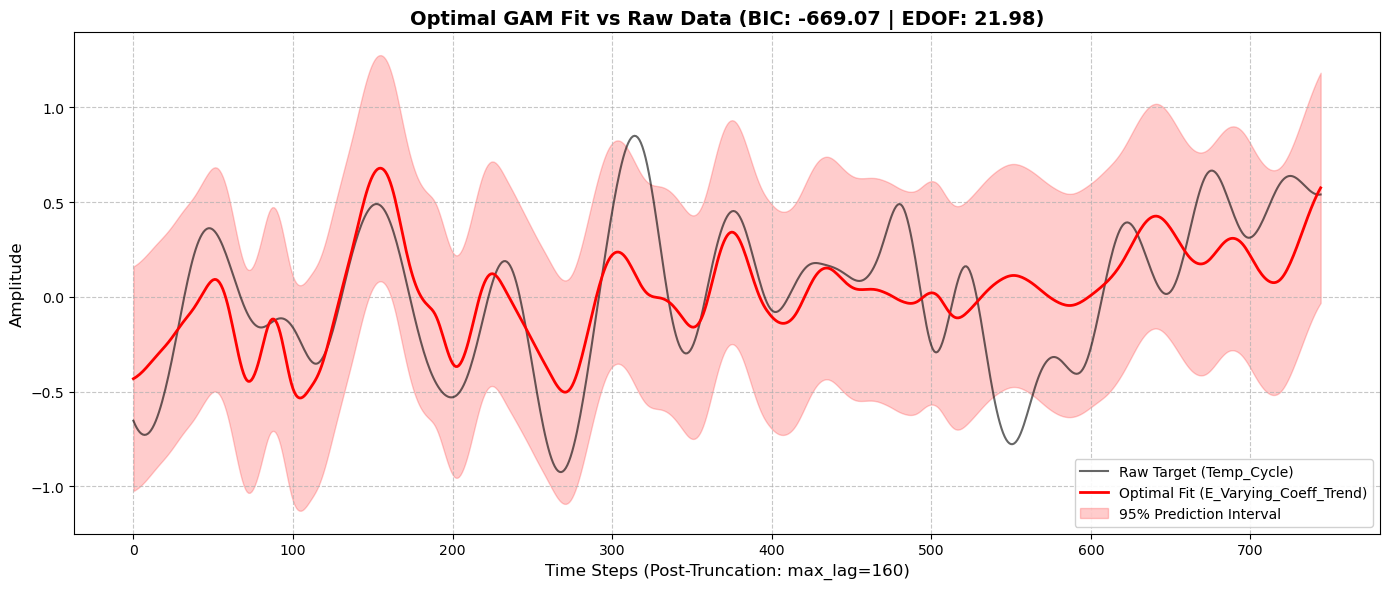

In [118]:
import pandas as pd
import numpy as np
import itertools
from pygam import LinearGAM, l, s, te
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. PARAMETERS AND LAG GRID DEFINITION
# ==============================================================================
lag_steps = [0,1,2,6,30, 60,90, 120, 160] 
lag_combinations = list(itertools.product(lag_steps, repeat=4))
max_lag = max(lag_steps)

print(f"Total lag combinations to test: {len(lag_combinations)}")
print(f"Aligning all matrices to universal max lag limit: {max_lag} months...")

# Extract pure raw vectors
nao_raw = df_gam_filtered['NAO_Cycle'].values
ea_raw = df_gam_filtered['EA_Cycle'].values
sca_raw = df_gam_filtered['SCA_Cycle'].values
amo_raw = df_gam_filtered['AMO_Cycle'].values
y_raw = df_gam_filtered['Temp_Cycle'].values
trend_raw = df_gam_filtered['Global_Warming'].values 

# Stationary targets
y_base = y_raw[max_lag:]
trend_base = trend_raw[max_lag:]
n_samples = len(y_base)

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
# We define a dictionary of formulations to test exhaustively.
# Spline degrees and basis functions are kept minimal to enforce simplicity.

formulations = {
    "A_Strict_Linear": l(0) + l(1) + l(2) + l(3) + l(4),
    
    "B_Linear_Cycles_Spline_Trend": l(0) + l(1) + l(2) + l(3) + s(4, spline_order=2, n_splines=5),
    
    "C_Strict_Splines": s(0, spline_order=2, n_splines=5) + 
                        s(1, spline_order=2, n_splines=5) + 
                        s(2, spline_order=2, n_splines=5) + 
                        s(3, spline_order=2, n_splines=5) + 
                        s(4, spline_order=2, n_splines=5),
                        
    "D_Trend_Dependent_Tensors": te(0, 4, n_splines=(4, 4)) + 
                                 te(1, 4, n_splines=(4, 4)) + 
                                 te(2, 4, n_splines=(4, 4)) + 
                                 te(3, 4, n_splines=(4, 4)),

"E_Varying_Coeff_Trend": l(0) + l(1) + l(2) + l(3) + s(4, n_splines=5) + 
                             s(4, by=0, n_splines=5) + 
                             s(4, by=1, n_splines=5) + 
                             s(4, by=2, n_splines=5) + 
                             s(4, by=3, n_splines=5),
                             
    # F. Teleconnection Coupling: Interaction between specific atmospheric/oceanic variables
    # 0 (NAO) couples with 1 (EA); 2 (SCA) couples with 3 (AMO)
    "F_Teleconnection_Coupling": te(0, 1, n_splines=(4, 4)) + 
                                 te(2, 3, n_splines=(4, 4)) + 
                                 l(4),
                                 
    # G. Mixed Dynamics: Fast Atmospheric (Linear) vs Slow Oceanic/Thermodynamic (Spline)
    "G_Mixed_Fast_Slow": l(0) + l(1) + l(2) + 
                         s(3, spline_order=2, n_splines=5) + 
                         s(4, spline_order=2, n_splines=5),    
    "H_Selective_VC_Modulation": l(0) + l(1) + l(2) + l(3) + s(4, n_splines=5) + 
                                 s(4, by=0, n_splines=5) + 
                                 s(4, by=1, n_splines=5) + 
                                 s(4, by=3, n_splines=5),
                                 
    # I. Stiff Varying Coefficients: Force the trend spline to be rigid (spline_order=1, min splines)
    "I_Stiff_VC_Trend": l(0) + l(1) + l(2) + l(3) + s(4, spline_order=1, n_splines=4) + 
                        s(4, by=0, spline_order=1, n_splines=4) + 
                        s(4, by=1, spline_order=1, n_splines=4) + 
                        s(4, by=2, spline_order=1, n_splines=4) + 
                        s(4, by=3, spline_order=1, n_splines=4),

    # J. Coupled NAO/EA Surface + Modulated AMO: 
    # NAO(0) and EA(1) as a 2D tensor; AMO(3) modulated by the Trend(4)
    "J_Coupled_NAO_EA_Modulated": te(0, 1, n_splines=(4, 4)) + l(2) + l(3) + 
                                  s(4, n_splines=5) + s(4, by=3, n_splines=5)
    
    
}

# ==============================================================================
# 3. EXHAUSTIVE GRID SEARCH EXECUTION
# ==============================================================================
results = []
total_tests = len(lag_combinations) * len(formulations)
current_test = 0

print("-" * 60)
print(f"Executing Multi-Architecture Global Lag Test ({total_tests} total fits)...")

for nao_lag, ea_lag, sca_lag, amo_lag in lag_combinations:
    
    # Shift variables
    nao_shifted = pd.Series(nao_raw).shift(nao_lag).values[max_lag:]
    ea_shifted  = pd.Series(ea_raw).shift(ea_lag).values[max_lag:]
    sca_shifted = pd.Series(sca_raw).shift(sca_lag).values[max_lag:]
    amo_shifted = pd.Series(amo_raw).shift(amo_lag).values[max_lag:]
    
    X_matrix = np.column_stack((nao_shifted, ea_shifted, sca_shifted, amo_shifted, trend_base))
        
    for form_name, formulation in formulations.items():
        current_test += 1
        
        try:
            model = LinearGAM(formulation)
            model.gridsearch(X_matrix, y_base, progress=False)
            
            aic = model.statistics_['AIC']
            edof = model.statistics_['edof']
            bic = aic + edof * (np.log(n_samples) - 2)
            
            results.append({
                "Model_Architecture": form_name,
                "NAO_Lag": nao_lag,
                "EA_Lag": ea_lag,
                "SCA_Lag": sca_lag,
                "AMO_Lag": amo_lag,
                "AIC": round(aic, 2),
                "BIC": round(bic, 2),
                "Pseudo_R2": round(model.statistics_['pseudo_r2']['explained_deviance'], 4),
                "EDOF": round(edof, 2)
            })
            
            if current_test % 100 == 0 or current_test == total_tests:
                current_best = min([r['BIC'] for r in results])
                print(f"[{current_test}/{total_tests}] Processed. Current Best BIC: {current_best}")
                
        except Exception as e:
            print(f"Failed on {form_name} with lag {nao_lag, ea_lag, sca_lag, amo_lag}: {e}")

# ==============================================================================
# 4. DIAGNOSTICS AND RANKING
# ==============================================================================
if not results:
    raise ValueError("No configurations were successfully processed. Check data alignment.")

df_results = pd.DataFrame(results)
df_ranked = df_results.sort_values(by="BIC", ascending=True).reset_index(drop=True)

print("\n" + "="*110)
print("EXHAUSTIVE ARCHITECTURE & LAG RANKING (TOP 15 CONFIGURATIONS)")
print("="*110)
print(df_ranked.head(15).to_string(index=False))

# ==============================================================================
# 5. VISUALIZATION OF THE OPTIMAL MODEL
# ==============================================================================
# Extract the absolute best configuration
best_config = df_ranked.iloc[0]
best_form_name = best_config['Model_Architecture']
best_nao_lag = int(best_config['NAO_Lag'])
best_ea_lag = int(best_config['EA_Lag'])
best_sca_lag = int(best_config['SCA_Lag'])
best_amo_lag = int(best_config['AMO_Lag'])

print(f"\nReconstructing: {best_form_name} with lags: NAO({best_nao_lag}), EA({best_ea_lag}), SCA({best_sca_lag}), AMO({best_amo_lag})")

# Re-shift the variables
best_nao_shifted = pd.Series(nao_raw).shift(best_nao_lag).values[max_lag:]
best_ea_shifted  = pd.Series(ea_raw).shift(best_ea_lag).values[max_lag:]
best_sca_shifted = pd.Series(sca_raw).shift(best_sca_lag).values[max_lag:]
best_amo_shifted = pd.Series(amo_raw).shift(best_amo_lag).values[max_lag:]

X_best = np.column_stack((best_nao_shifted, best_ea_shifted, best_sca_shifted, best_amo_shifted, trend_base))

# Fit the optimal GAM
best_formulation = formulations[best_form_name]
best_model = LinearGAM(best_formulation)
best_model.fit(X_best, y_base)

y_pred = best_model.predict(X_best)
y_intervals = best_model.prediction_intervals(X_best, width=0.95)

plt.figure(figsize=(14, 6))
time_steps = np.arange(len(y_base))

plt.plot(time_steps, y_base, label='Raw Target (Temp_Cycle)', color='black', alpha=0.6, linewidth=1.5)
plt.plot(time_steps, y_pred, label=f'Optimal Fit ({best_form_name})', color='red', linewidth=2)
plt.fill_between(time_steps, y_intervals[:, 0], y_intervals[:, 1], color='red', alpha=0.2, label='95% Prediction Interval')

plt.title(f'Optimal GAM Fit vs Raw Data (BIC: {best_config["BIC"]} | EDOF: {best_config["EDOF"]})', fontsize=14, fontweight='bold')
plt.xlabel(f'Time Steps (Post-Truncation: max_lag={max_lag})', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Total lag combinations to test: 1
Aligning all matrices to universal max lag limit: 45 months...
------------------------------------------------------------
Executing Multi-Architecture Global Lag Test (1 total fits)...
[1/1] Processed. Current Best BIC: 625.18

EXHAUSTIVE ARCHITECTURE & LAG RANKING (TOP 15 CONFIGURATIONS)
                 Model_Architecture  NAO_Lag  EA_Lag  SCA_Lag  AMO_Lag   AIC    BIC  Pseudo_R2  EDOF
simple_filtered_Varying_Coeff_Trend       45      45       45       45 601.4 625.18      0.318   5.0

Reconstructing: simple_filtered_Varying_Coeff_Trend with lags: NAO(45), EA(45), SCA(45), AMO(45)


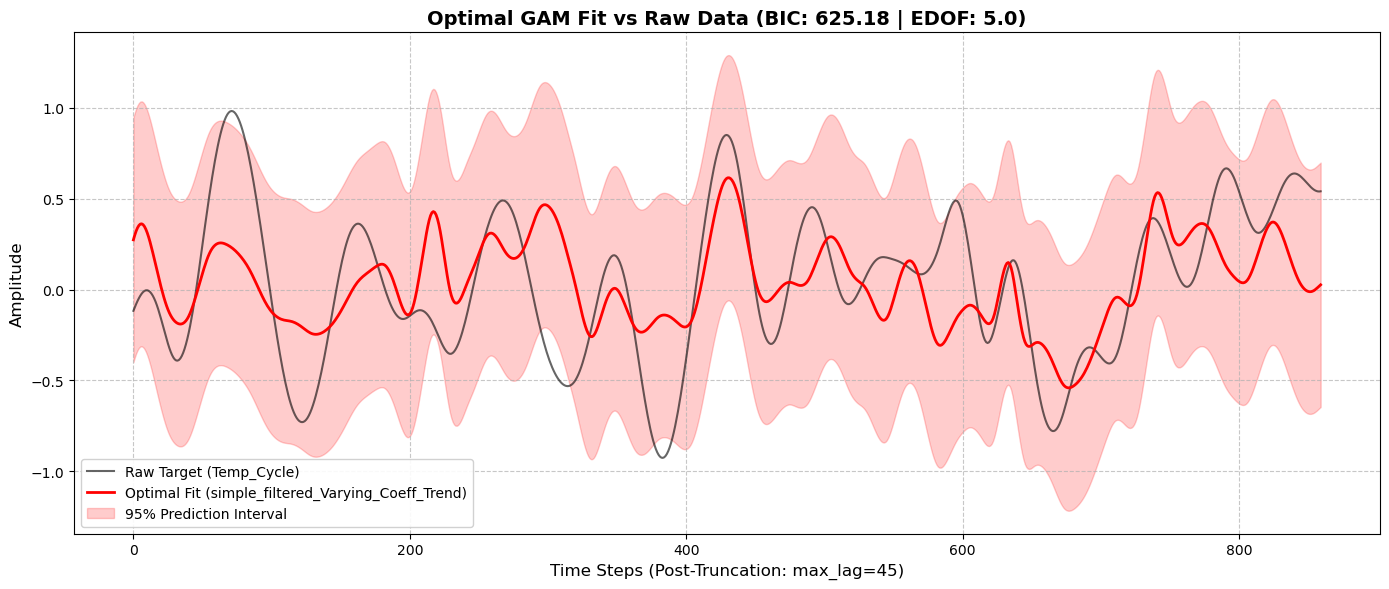


EXACT MODEL COEFFICIENTS (BASIS FUNCTION WEIGHTS)
Term 0 -> spline_term:
 [-1.86235121 -1.32399159]

Term 1 -> spline_term:
 [0.42786231 0.96415234]

Intercept:
 0.033779


Generating component evolution plots...


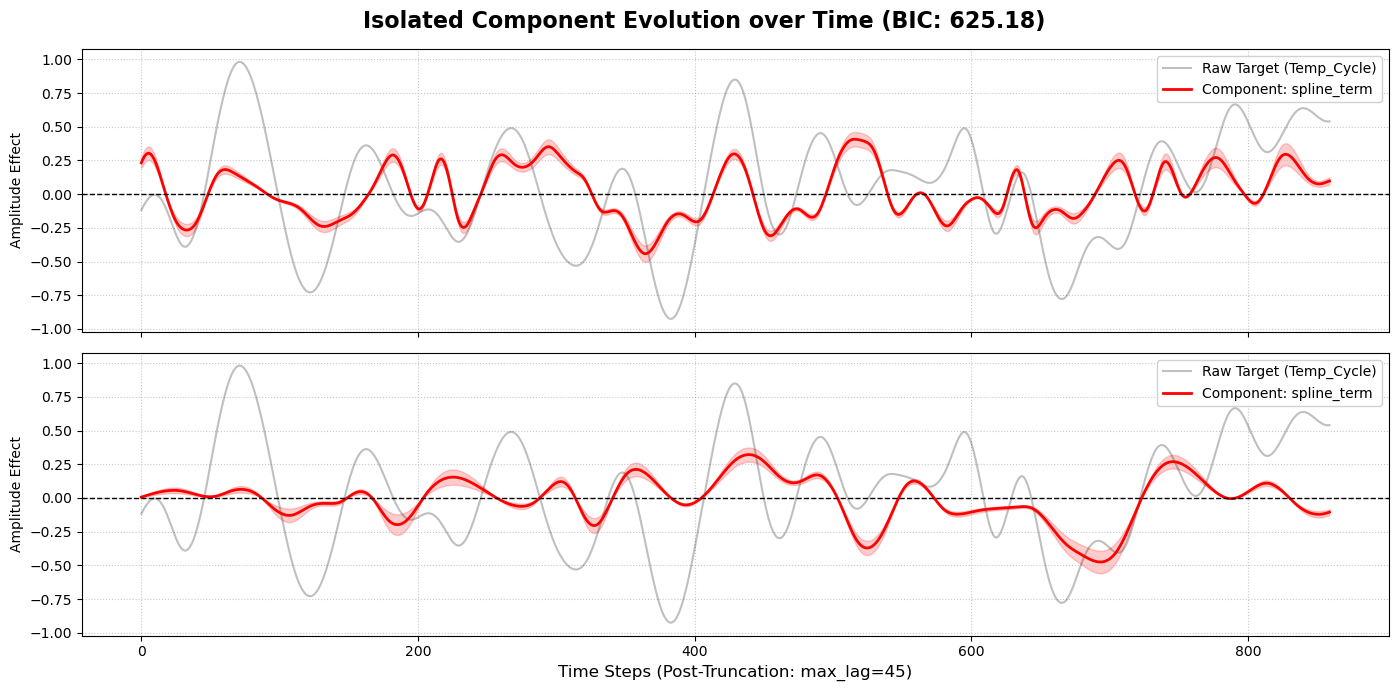


Generating static spline shape visualizations...


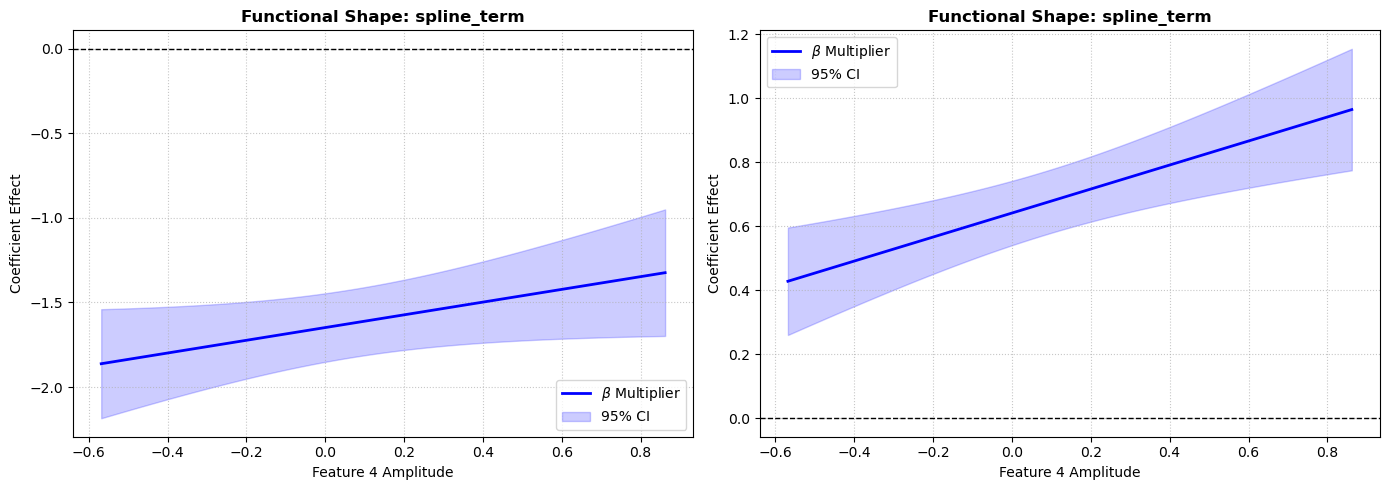

In [233]:
import pandas as pd
import numpy as np
import itertools
from pygam import LinearGAM, l, s, te
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. PARAMETERS AND LAG GRID DEFINITION
# ==============================================================================
lag_steps = [45] 
lag_combinations = list(itertools.product(lag_steps, repeat=4))
max_lag = max(lag_steps)

print(f"Total lag combinations to test: {len(lag_combinations)}")
print(f"Aligning all matrices to universal max lag limit: {max_lag} months...")

# Extract pure raw vectors
nao_raw = df_gam_filtered['NAO_Cycle'].values
ea_raw = df_gam_filtered['EA_Cycle'].values
sca_raw = df_gam_filtered['SCA_Cycle'].values
amo_raw = df_gam_filtered['AMO_Cycle'].values
y_raw = df_gam_filtered['Temp_Cycle'].values
trend_raw = df_gam_filtered['Global_Warming'].values
direct_nao = df_gam_filtered['NAO_Cycle'].values

# Stationary targets
y_base = y_raw[max_lag:]
trend_base = trend_raw[max_lag:]
direct_nao_base = direct_nao[max_lag:]
n_samples = len(y_base)

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
# We define a dictionary of formulations to test exhaustively.
# Spline degrees and basis functions are kept minimal to enforce simplicity.


# Variable 0 (NAO): Gentle monotonic curve -> Reduce to 4 splines
nao_mod = s(4, by=0, n_splines=4)

# Variable 1 (EA): Phase inversion curve -> Reduce to 4 splines
ea_mod = s(4, by=1, n_splines=4)

# Variable 2 (SCA): U-Shape -> Keep 5 splines to allow quadratic curve
sca_mod = s(4, by=2, n_splines=5)

# Variable 3 (AMO): Perfect straight line -> Force linear spline order
amo_mod = s(4, by=3, n_splines=4)


physics_informed_formulation = nao_mod + ea_mod + sca_mod + amo_mod


# 2. VCs constrained to absolute minimum splines
nao_mod_2 = s(4, by=5, n_splines=4)
nao_mod_2_s = s(4, by=5, spline_order=1, n_splines=2)
amo_mod_s = s(4, by=3, spline_order=1,n_splines=2)

filtered_formulation = nao_mod + amo_mod + nao_mod_2

simple_filtered_formulation = amo_mod_s + nao_mod_2_s
# Combine into the final optimized formulation
physics_informed_formulation_2 = nao_mod + ea_mod_2 + sca_mod_2 + amo_mod_2
formulations = {
#"Ebis_Varying_Coeff_Trend":  physics_informed_formulation,
#"Ebis_Varying_Coeff_Trend":  physics_informed_formulation,
"simple_filtered_Varying_Coeff_Trend":  simple_filtered_formulation
}

# ==============================================================================
# 3. EXHAUSTIVE GRID SEARCH EXECUTION
# ==============================================================================
results = []
total_tests = len(lag_combinations) * len(formulations)
current_test = 0

print("-" * 60)
print(f"Executing Multi-Architecture Global Lag Test ({total_tests} total fits)...")

for nao_lag, ea_lag, sca_lag, amo_lag in lag_combinations:
    
    # Shift variables
    nao_shifted = pd.Series(nao_raw).shift(nao_lag).values[max_lag:]
    ea_shifted  = pd.Series(ea_raw).shift(ea_lag).values[max_lag:]
    sca_shifted = pd.Series(sca_raw).shift(sca_lag).values[max_lag:]
    amo_shifted = pd.Series(amo_raw).shift(amo_lag).values[max_lag:]
    
    X_matrix = np.column_stack((nao_shifted, ea_shifted, sca_shifted, amo_shifted, trend_base, direct_nao_base))
        
    for form_name, formulation in formulations.items():
        current_test += 1
        
        try:
            model = LinearGAM(formulation)
            model.gridsearch(X_matrix, y_base, progress=False)
            
            aic = model.statistics_['AIC']
            edof = model.statistics_['edof']
            bic = aic + edof * (np.log(n_samples) - 2)
            
            results.append({
                "Model_Architecture": form_name,
                "NAO_Lag": nao_lag,
                "EA_Lag": ea_lag,
                "SCA_Lag": sca_lag,
                "AMO_Lag": amo_lag,
                "AIC": round(aic, 2),
                "BIC": round(bic, 2),
                "Pseudo_R2": round(model.statistics_['pseudo_r2']['explained_deviance'], 4),
                "EDOF": round(edof, 2)
            })
            
            if current_test % 100 == 0 or current_test == total_tests:
                current_best = min([r['BIC'] for r in results])
                print(f"[{current_test}/{total_tests}] Processed. Current Best BIC: {current_best}")
                
        except Exception as e:
            print(f"Failed on {form_name} with lag {nao_lag, ea_lag, sca_lag, amo_lag}: {e}")

# ==============================================================================
# 4. DIAGNOSTICS AND RANKING
# ==============================================================================
if not results:
    raise ValueError("No configurations were successfully processed. Check data alignment.")

df_results = pd.DataFrame(results)
df_ranked = df_results.sort_values(by="BIC", ascending=True).reset_index(drop=True)

print("\n" + "="*110)
print("EXHAUSTIVE ARCHITECTURE & LAG RANKING (TOP 15 CONFIGURATIONS)")
print("="*110)
print(df_ranked.head(15).to_string(index=False))

# ==============================================================================
# 5. VISUALIZATION OF THE OPTIMAL MODEL
# ==============================================================================
# Extract the absolute best configuration
best_config = df_ranked.iloc[0]
best_form_name = best_config['Model_Architecture']
best_nao_lag = int(best_config['NAO_Lag'])
best_ea_lag = int(best_config['EA_Lag'])
best_sca_lag = int(best_config['SCA_Lag'])
best_amo_lag = int(best_config['AMO_Lag'])

print(f"\nReconstructing: {best_form_name} with lags: NAO({best_nao_lag}), EA({best_ea_lag}), SCA({best_sca_lag}), AMO({best_amo_lag})")

# Re-shift the variables
best_nao_shifted = pd.Series(nao_raw).shift(best_nao_lag).values[max_lag:]
best_ea_shifted  = pd.Series(ea_raw).shift(best_ea_lag).values[max_lag:]
best_sca_shifted = pd.Series(sca_raw).shift(best_sca_lag).values[max_lag:]
best_amo_shifted = pd.Series(amo_raw).shift(best_amo_lag).values[max_lag:]

X_best = np.column_stack((best_nao_shifted, best_ea_shifted, best_sca_shifted, best_amo_shifted, trend_base, direct_nao_base))

# Fit the optimal GAM
best_formulation = formulations[best_form_name]
best_model = LinearGAM(best_formulation)
best_model.fit(X_best, y_base)

y_pred = best_model.predict(X_best)
y_intervals = best_model.prediction_intervals(X_best, width=0.95)

plt.figure(figsize=(14, 6))
time_steps = np.arange(len(y_base))

plt.plot(time_steps, y_base, label='Raw Target (Temp_Cycle)', color='black', alpha=0.6, linewidth=1.5)
plt.plot(time_steps, y_pred, label=f'Optimal Fit ({best_form_name})', color='red', linewidth=2)
plt.fill_between(time_steps, y_intervals[:, 0], y_intervals[:, 1], color='red', alpha=0.2, label='95% Prediction Interval')

plt.title(f'Optimal GAM Fit vs Raw Data (BIC: {best_config["BIC"]} | EDOF: {best_config["EDOF"]})', fontsize=14, fontweight='bold')
plt.xlabel(f'Time Steps (Post-Truncation: max_lag={max_lag})', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
# ==============================================================================
# 6. EXACT COEFFICIENT EXTRACTION
# ==============================================================================
print("\n" + "="*85)
print("EXACT MODEL COEFFICIENTS (BASIS FUNCTION WEIGHTS)")
print("="*85)

# The total coefficient array
raw_coefs = best_model.coef_

start_idx = 0
for i, term in enumerate(best_model.terms):
    # Determine the number of coefficients for the current term
    n_coefs = term.n_coefs
    end_idx = start_idx + n_coefs
    
    # Slice the raw coefficient array
    term_coefs = raw_coefs[start_idx:end_idx]
    
    if term.isintercept:
        print(f"Intercept:\n {term_coefs[0]:.6f}\n")
    else:
        # Format the term representation for readability
        term_str = str(term).replace('\n', '').strip()
        print(f"Term {i} -> {term_str}:")
        print(f" {term_coefs}\n")
        
    start_idx = end_idx


# ==============================================================================
# 7. TEMPORAL EVOLUTION OF INDIVIDUAL COMPONENTS (DYNAMIC)
# ==============================================================================
print("\nGenerating component evolution plots...")

# Dynamically extract all valid (non-intercept) terms from the model
valid_terms = [(i, term) for i, term in enumerate(best_model.terms) if not term.isintercept]
n_terms = len(valid_terms)

if n_terms == 0:
    raise ValueError("The model contains no valid splines to plot.")

# Initialize dynamic subplots based on the exact number of active components
fig, axes = plt.subplots(n_terms, 1, figsize=(14, 3.5 * n_terms), sharex=True)

# Ensure axes is iterable even if there is only 1 term left in the model
if n_terms == 1:
    axes = [axes]

time_steps = np.arange(len(y_base))

for ax, (term_idx, term) in zip(axes, valid_terms):
    
    # Generate a dynamic title based on the underlying spline formula
    term_str = str(term).replace('\n', '').strip()
    title = f"Component: {term_str}"
    
    # 1. Extract the isolated temporal contribution
    component_evolution, confi_intervals = best_model.partial_dependence(term=term_idx, X=X_best, width=0.95)
    
    # 2. Plot Raw Target (Background reference)
    ax.plot(time_steps, y_base, color='black', alpha=0.25, linewidth=1.5, label='Raw Target (Temp_Cycle)')
    
    # 3. Plot Component Evolution
    ax.plot(time_steps, component_evolution, color='red', linewidth=2, label=title)
    
    # 4. Plot 95% Confidence Interval
    ax.fill_between(time_steps, confi_intervals[:, 0], confi_intervals[:, 1], color='red', alpha=0.2)
    
    # Formatting
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Amplitude Effect', fontsize=10)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, linestyle=':', alpha=0.7)

# Global formatting
plt.suptitle(f'Isolated Component Evolution over Time (BIC: {best_config["BIC"]})', fontsize=16, fontweight='bold', y=0.98)
plt.xlabel(f'Time Steps (Post-Truncation: max_lag={max_lag})', fontsize=12)
plt.tight_layout()

# Execute plot
plt.show()

# ==============================================================================
# 8. SPLINE SHAPE VISUALIZATION (PARTIAL DEPENDENCE CURVES)
# ==============================================================================
print("\nGenerating static spline shape visualizations...")

# Dynamically extract all valid (non-intercept) terms from the model
valid_terms = [(i, term) for i, term in enumerate(best_model.terms) if not term.isintercept]
n_terms = len(valid_terms)

if n_terms == 0:
    raise ValueError("The model contains no valid splines to plot.")

# Set up a dynamic grid for the subplots (2 columns, auto-calculating rows)
cols = 2
rows = int(np.ceil(n_terms / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))

# Flatten axes array for easy iteration, handling cases where there's only 1 row or 1 plot
axes = np.atleast_1d(axes).flatten()

for idx, (term_idx, term) in enumerate(valid_terms):
    ax = axes[idx]
    
    # 1. Generate a synthetic grid of 100 points strictly for this term
    XX = best_model.generate_X_grid(term=term_idx)
    
    # 2. Extract the partial dependence (beta multiplier) and confidence intervals
    pdep, confi = best_model.partial_dependence(term=term_idx, X=XX, width=0.95)
    
    # 3. Isolate the X-axis values. 
    # term.feature gives the integer column index of the primary variable in X_matrix (e.g., 4 for Trend)
    feature_idx = term.feature
    x_grid = XX[:, feature_idx]
    
    term_str = str(term).replace('\n', '').strip()
    
    # 4. Plotting
    ax.plot(x_grid, pdep, color='blue', linewidth=2, label=r'$\beta$ Multiplier')
    ax.fill_between(x_grid, confi[:, 0], confi[:, 1], color='blue', alpha=0.2, label='95% CI')
    
    # Add zero-line to easily identify phase inversions
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    
    ax.set_title(f'Functional Shape: {term_str}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Feature {feature_idx} Amplitude', fontsize=10)
    ax.set_ylabel('Coefficient Effect', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.7)

# Remove any empty subplots if n_terms is odd
for idx in range(n_terms, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [232]:
import pandas as pd
import numpy as np
import itertools
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, r2_score

def grid_search_lags_cv(
    df: pd.DataFrame, 
    target_col: str, 
    lag_grid: dict, 
    static_features: list, 
    model_factory: callable, 
    n_splits: int = 5
) -> pd.DataFrame:
    """
    Evaluates different lag combinations for time-series features using K-Fold CV.
    
    Parameters:
    df (pd.DataFrame): The dataset containing all features and the target.
    target_col (str): The name of the target variable.
    lag_grid (dict): Dictionary mapping feature names to a list of integer lags to test.
                     e.g., {'NAO': [0, 60], 'EA': [160]}
    static_features (list): Features that should NOT be lagged (e.g., background trend).
    model_factory (callable): A function/lambda that returns a fresh, un-fitted model instance.
    n_splits (int): Number of K-Fold splits.
    
    Returns:
    pd.DataFrame: Ranked results sorted by Mean Out-of-Fold RMSE.
    """
    
    # 1. Determine the universal truncation limit to keep sample size constant
    max_lag_overall = max([max(lags) for lags in lag_grid.values()])
    print(f"Universal max lag limit set to: {max_lag_overall} steps.")
    
    # 2. Extract stationary base targets and static features
    y_base = df[target_col].values[max_lag_overall:]
    static_matrix = df[static_features].values[max_lag_overall:]
    
    # 3. Generate all permutations from the lag grid
    feature_names = list(lag_grid.keys())
    lag_combinations = list(itertools.product(*lag_grid.values()))
    
    # Initialize Time-Series safe K-Fold (no shuffling)
    kf = TimeSeriesSplit(n_splits=n_splits, test_size=len(y_base)//10)
    results = []
    
    total_tests = len(lag_combinations)
    print(f"Executing K-Fold CV across {total_tests} configurations...\n")
    
    # 4. Exhaustive Grid Search
    for idx, current_lags in enumerate(lag_combinations, 1):
        
        # Build the dynamic shifted feature matrix for this combination
        shifted_features = []
        for feature, lag in zip(feature_names, current_lags):
            shifted_col = df[feature].shift(lag).values[max_lag_overall:]
            shifted_features.append(shifted_col)
            
        # Combine shifted features with static features
        X_matrix = np.column_stack([*shifted_features, static_matrix])
        
        # K-Fold CV Loop
        fold_rmse = []
        fold_r2 = []
        
        for train_idx, test_idx in kf.split(X_matrix):
            X_train, X_test = X_matrix[train_idx], X_matrix[test_idx]
            y_train, y_test = y_base[train_idx], y_base[test_idx]
            
            # Instantiate a fresh model to prevent state leakage
            model = model_factory()
            
            try:
                # Fit and predict
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                
                # Calculate Out-of-Fold metrics
                fold_rmse.append(root_mean_squared_error(y_test, preds))
                fold_r2.append(r2_score(y_test, preds))
                
            except Exception as e:
                print(f"Fold failed for lags {current_lags}: {e}")
                fold_rmse.append(np.nan)
                fold_r2.append(np.nan)
        
        # Aggregate Results
        res_dict = {f"{feat}_Lag": lag for feat, lag in zip(feature_names, current_lags)}
        res_dict.update({
            "Mean_CV_RMSE": np.nanmean(fold_rmse),
            "Std_CV_RMSE": np.nanstd(fold_rmse),
            "Mean_CV_R2": np.nanmean(fold_r2)
        })
        results.append(res_dict)
        
        if idx % 20 == 0 or idx == total_tests:
            print(f"[{idx}/{total_tests}] Processed.")
            
    # 5. Format and Rank Output
    df_results = pd.DataFrame(results)
    df_ranked = df_results.sort_values(by="Mean_CV_RMSE", ascending=True).reset_index(drop=True)
    
    return df_ranked


# Define the lag search space
lag_grid_params = {
    'NAO_Cycle': [0],
    'EA_Cycle': [160],
    'SCA_Cycle': [90],
    'AMO_Cycle': [45]
}

# Define features that do not shift
static_cols = ['Global_Warming']

# Define the optimal Varying Coefficient architecture
optimal_formulation = core_formulation

# Create a factory function for the model
gam_factory = lambda: LinearGAM(optimal_formulation, lam=20.0)

# Run the CV Grid Search
ranked_results = grid_search_lags_cv(
    df=df_gam_filtered,
    target_col='Temp_Cycle',
    lag_grid=lag_grid_params,
    static_features=static_cols,
    model_factory=gam_factory,
    n_splits=10
)

print(ranked_results.head(10).to_string(index=False))

Universal max lag limit set to: 160 steps.
Executing K-Fold CV across 1 configurations...

[1/1] Processed.
 NAO_Cycle_Lag  EA_Cycle_Lag  SCA_Cycle_Lag  AMO_Cycle_Lag  Mean_CV_RMSE  Std_CV_RMSE  Mean_CV_R2
             0           160             90             45      0.514068     0.169372   -5.524057


In [49]:
import pandas as pd
import numpy as np
import itertools
from pygam import LinearGAM, l, s, te
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit


# 1. Feature Extraction and Alignment
max_lag_overall = 48

# Instantaneous atmospheric forcing
nao_shifted = df_gam_filtered['NAO_Cycle'].shift(1).values[max_lag_overall:]

# 3.75-year delayed oceanic forcing
amo_shifted = df_gam_filtered['AMO_Cycle'].shift(48).values[max_lag_overall:]

y_base = df_gam_filtered['Temp_Cycle'].values[max_lag_overall:]

X_matrix_core = np.column_stack((nao_shifted, amo_shifted))

# 2. Lean Formulation
# Variable 0: NAO (Lag 0)
# Variable 1: AMO (Lag 45)
# Variable 2: Global Warming Trend

amo_formulation = l(1)
amo_formulation_2 = s(1, spline_order=1, n_splines=2)
linear_formulation =  (l(1) + l(0))
core_formulation = (
    s(2, by=1, spline_order=1, n_splines=2)   # AMO VC (Modulated by Trend)
)
core_formulation_2 = (
     # Stiff Background Trend
    s(1, by=0, spline_order=1, n_splines=2) + # NAO VC (Modulated by AMO)
    s(2, by=1, spline_order=1, n_splines=2) + # AMO VC (Modulated by Trend)
    s(2, by=0, spline_order=1, n_splines=2) # AO VC (Modulated by Trend)
)



tensor_formulation = (
     te(0, 1, n_splines=[4, 4])
)

tensor_formulation_2 = (
     te(0, 1, spline_order=1, n_splines=[2, 2])
)

In [51]:
df_new = pd.DataFrame(data={"NAO" : nao_shifted, "AMO" : amo_shifted, "trend" : df_gam_filtered['Global_Warming'][max_lag_overall:],'Temp_Cycle' : df_gam_filtered['Temp_Cycle'][max_lag_overall:]})

optimal_formulation = amo_formulation

# Create a factory function for the model
gam_factory = lambda: LinearGAM(optimal_formulation, lam=20.0)

def grid_search_lags_cv(
    df: pd.DataFrame, 
    target_col: str, 
    lag_grid: dict, 
    static_features: list, 
    model_factory: callable, 
    n_splits: int = 5
) -> pd.DataFrame:
    """
    Evaluates different lag combinations for time-series features using K-Fold CV.
    
    Parameters:
    df (pd.DataFrame): The dataset containing all features and the target.
    target_col (str): The name of the target variable.
    lag_grid (dict): Dictionary mapping feature names to a list of integer lags to test.
                     e.g., {'NAO': [0, 60], 'EA': [160]}
    static_features (list): Features that should NOT be lagged (e.g., background trend).
    model_factory (callable): A function/lambda that returns a fresh, un-fitted model instance.
    n_splits (int): Number of K-Fold splits.
    
    Returns:
    pd.DataFrame: Ranked results sorted by Mean Out-of-Fold RMSE.
    """
    
    # 1. Determine the universal truncation limit to keep sample size constant
    max_lag_overall = max([max(lags) for lags in lag_grid.values()])
    print(f"Universal max lag limit set to: {max_lag_overall} steps.")
    
    # 2. Extract stationary base targets and static features
    y_base = df[target_col].values[max_lag_overall:]
    static_matrix = df[static_features].values[max_lag_overall:]
    
    # 3. Generate all permutations from the lag grid
    feature_names = list(lag_grid.keys())
    lag_combinations = list(itertools.product(*lag_grid.values()))
    
    # Initialize Time-Series safe K-Fold (no shuffling)
    kf = TimeSeriesSplit(n_splits=n_splits, test_size=len(y_base)//10)
    results = []
    
    total_tests = len(lag_combinations)
    print(f"Executing K-Fold CV across {total_tests} configurations...\n")
    
    # 4. Exhaustive Grid Search
    for idx, current_lags in enumerate(lag_combinations, 1):
        
        # Build the dynamic shifted feature matrix for this combination
        shifted_features = []
        for feature, lag in zip(feature_names, current_lags):
            shifted_col = df[feature].shift(lag).values[max_lag_overall:]
            shifted_features.append(shifted_col)
            
        # Combine shifted features with static features
        X_matrix = np.column_stack([*shifted_features, static_matrix])
        
        # K-Fold CV Loop
        fold_rmse = []
        fold_r2 = []
        
        for train_idx, test_idx in kf.split(X_matrix):
            X_train, X_test = X_matrix[train_idx], X_matrix[test_idx]
            y_train, y_test = y_base[train_idx], y_base[test_idx]
            
            # Instantiate a fresh model to prevent state leakage
            model = model_factory()
            
            try:
                # Fit and predict
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                
                # Calculate Out-of-Fold metrics
                fold_rmse.append(root_mean_squared_error(y_test, preds))
                fold_r2.append(r2_score(y_test, preds))
                
            except Exception as e:
                print(f"Fold failed for lags {current_lags}: {e}")
                fold_rmse.append(np.nan)
                fold_r2.append(np.nan)
        
        # Aggregate Results
        res_dict = {f"{feat}_Lag": lag for feat, lag in zip(feature_names, current_lags)}
        res_dict.update({
            "Mean_CV_RMSE": np.nanmean(fold_rmse),
            "Std_CV_RMSE": np.nanstd(fold_rmse),
            "Mean_CV_R2": np.nanmean(fold_r2)
        })
        results.append(res_dict)
        
        if idx % 20 == 0 or idx == total_tests:
            print(f"[{idx}/{total_tests}] Processed.")
            
    # 5. Format and Rank Output
    df_results = pd.DataFrame(results)
    df_ranked = df_results.sort_values(by="Mean_CV_RMSE", ascending=True).reset_index(drop=True)
    
    return df_ranked

ranked_results = grid_search_lags_cv(
    df=df_new,
    target_col='Temp_Cycle',
    lag_grid={"NAO": [0]},
    static_features=["AMO", 'trend'],
    model_factory=gam_factory,
    n_splits=5
)

print(ranked_results.head(10).to_string(index=False))

Universal max lag limit set to: 0 steps.
Executing K-Fold CV across 1 configurations...

[1/1] Processed.
 NAO_Lag  Mean_CV_RMSE  Std_CV_RMSE  Mean_CV_R2
       0      0.312798     0.095687   -1.182788


https://iopscience.iop.org/article/10.1088/1748-9326/aba925


Generating the 3D Bilinear Interaction Surface...


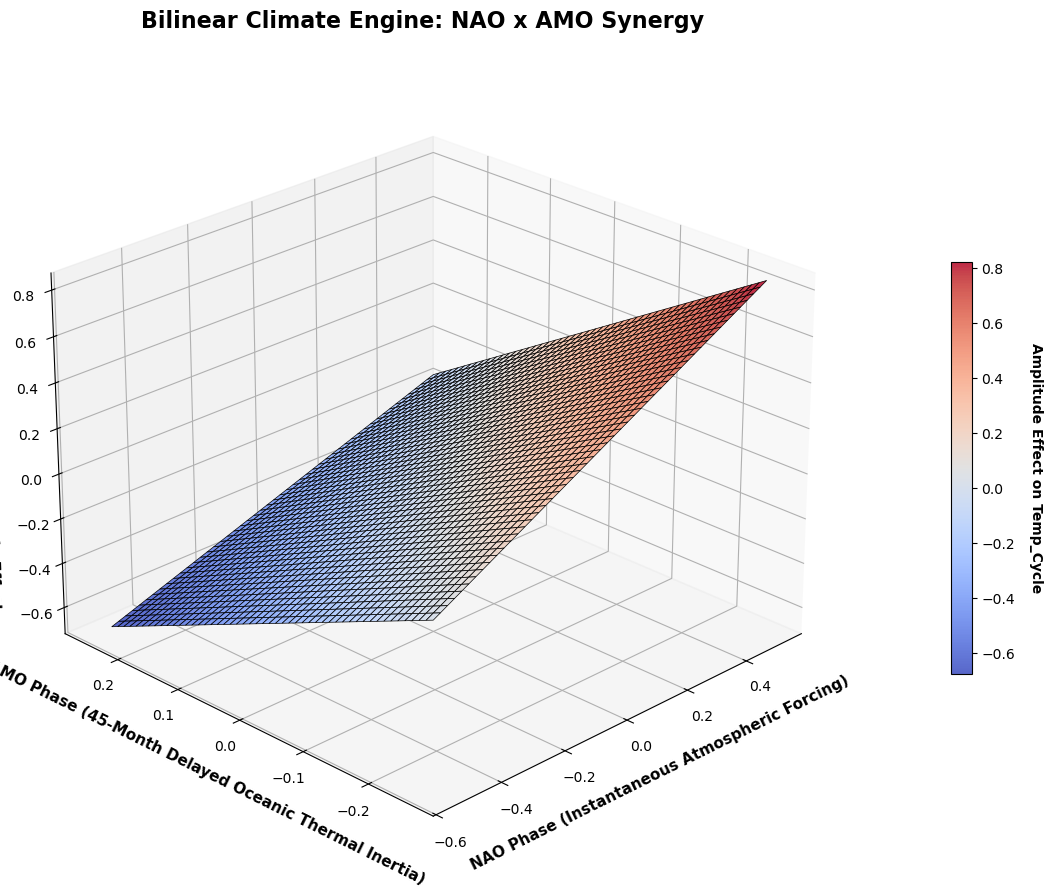

In [265]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from pygam import LinearGAM, te

# ==============================================================================
# 1. FIT THE OPTIMAL BILINEAR TENSOR MODEL
# ==============================================================================
# Assuming X_matrix_core is: Col 0 -> NAO (Lag 0), Col 1 -> AMO (Lag 45)
# We enforce spline_order=1 and n_splines=2 to create a strict bilinear surface
optimal_tensor_formulation = te(0, 1, spline_order=1, n_splines=[2, 2])

# Fit with your established penalization
final_model = LinearGAM(optimal_tensor_formulation, lam=50.0)
final_model.fit(X_matrix_core, y_base)

# ==============================================================================
# 2. FINAL VISUALIZATION: THE 3D CLIMATE INTERACTION ENGINE
# ==============================================================================
print("\nGenerating the 3D Bilinear Interaction Surface...")

# A. Generate a dense 50x50 coordinate grid across the physical ranges of NAO and AMO
XX_tensor = final_model.generate_X_grid(term=0, meshgrid=True, n=50)

# B. Extract the predicted temperature anomaly (Z-axis) across this grid
# FIX: Remove the tuple unpacking (`, _`). It returns a single 2D array.
Z_surface = final_model.partial_dependence(term=0, X=XX_tensor, meshgrid=True)

# C. Isolate the spatial axes directly from the tensor list
# FIX: Extract the 2D meshgrids directly
X_nao = XX_tensor[0]  # NAO Phase physical values
Y_amo = XX_tensor[1]  # AMO Phase physical values

# D. Construct the 3D Projection
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X_nao, Y_amo, Z_surface, 
                       cmap='coolwarm', 
                       edgecolor='black', 
                       linewidth=0.5, 
                       alpha=0.85)

# Formatting and Physical Labels
ax.set_title('Bilinear Climate Engine: NAO x AMO Synergy', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('\nNAO Phase (Instantaneous Atmospheric Forcing)', fontsize=11, fontweight='bold')
ax.set_ylabel('\nAMO Phase (45-Month Delayed Oceanic Thermal Inertia)', fontsize=11, fontweight='bold')
ax.set_zlabel('\nTarget Temperature Anomaly Effect', fontsize=11, fontweight='bold')

# Quantifiable Color Bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Amplitude Effect on Temp_Cycle', rotation=270, labelpad=20, fontweight='bold')

# Optimal viewing angle to expose the structural "twist" of the interaction
ax.view_init(elev=25, azim=225)

plt.tight_layout()
plt.show()

In [216]:
import numpy as np
baseline_std = np.std(df_gam_filtered['Temp_Cycle'].values[max_lag_overall:])
print(f"Global Target Standard Deviation: {baseline_std:.6f}")

Global Target Standard Deviation: 0.412763


In [184]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np

# 1. Initialize TimeSeriesSplit (Matching your previous setup)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# 2. Initialize Ridge Regression (Alpha is the L2 penalty, similar to GAM's lam)
ridge_model = Ridge(alpha=100.0)

fold_rmse = []
fold_r2 = []

print("-" * 50)
print("PURE LINEAR RIDGE REGRESSION CV (THE FINAL BASELINE)")
print("-" * 50)

for train_idx, test_idx in tscv.split(X_matrix_core):
    X_train, X_test = X_matrix_core[train_idx], X_matrix_core[test_idx]
    y_train, y_test = y_base[train_idx], y_base[test_idx]
    
    # Fit and Predict
    ridge_model.fit(X_train, y_train)
    preds = ridge_model.predict(X_test)
    
    # Calculate Metrics
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    fold_rmse.append(rmse)
    fold_r2.append(r2)
    
    print(f"Fold R2: {r2:8.4f} | RMSE: {rmse:8.4f}")

print("-" * 50)
print(f"Mean CV RMSE: {np.mean(fold_rmse):.4f}")
print(f"Mean CV R2:   {np.mean(fold_r2):.4f}")

--------------------------------------------------
PURE LINEAR RIDGE REGRESSION CV (THE FINAL BASELINE)
--------------------------------------------------
Fold R2:  -0.0557 | RMSE:   0.2641
Fold R2:  -0.2706 | RMSE:   0.5198
Fold R2:  -0.5566 | RMSE:   0.3111
Fold R2:  -0.2784 | RMSE:   0.4028
Fold R2:  -3.7273 | RMSE:   0.4708
--------------------------------------------------
Mean CV RMSE: 0.3937
Mean CV R2:   -0.9777


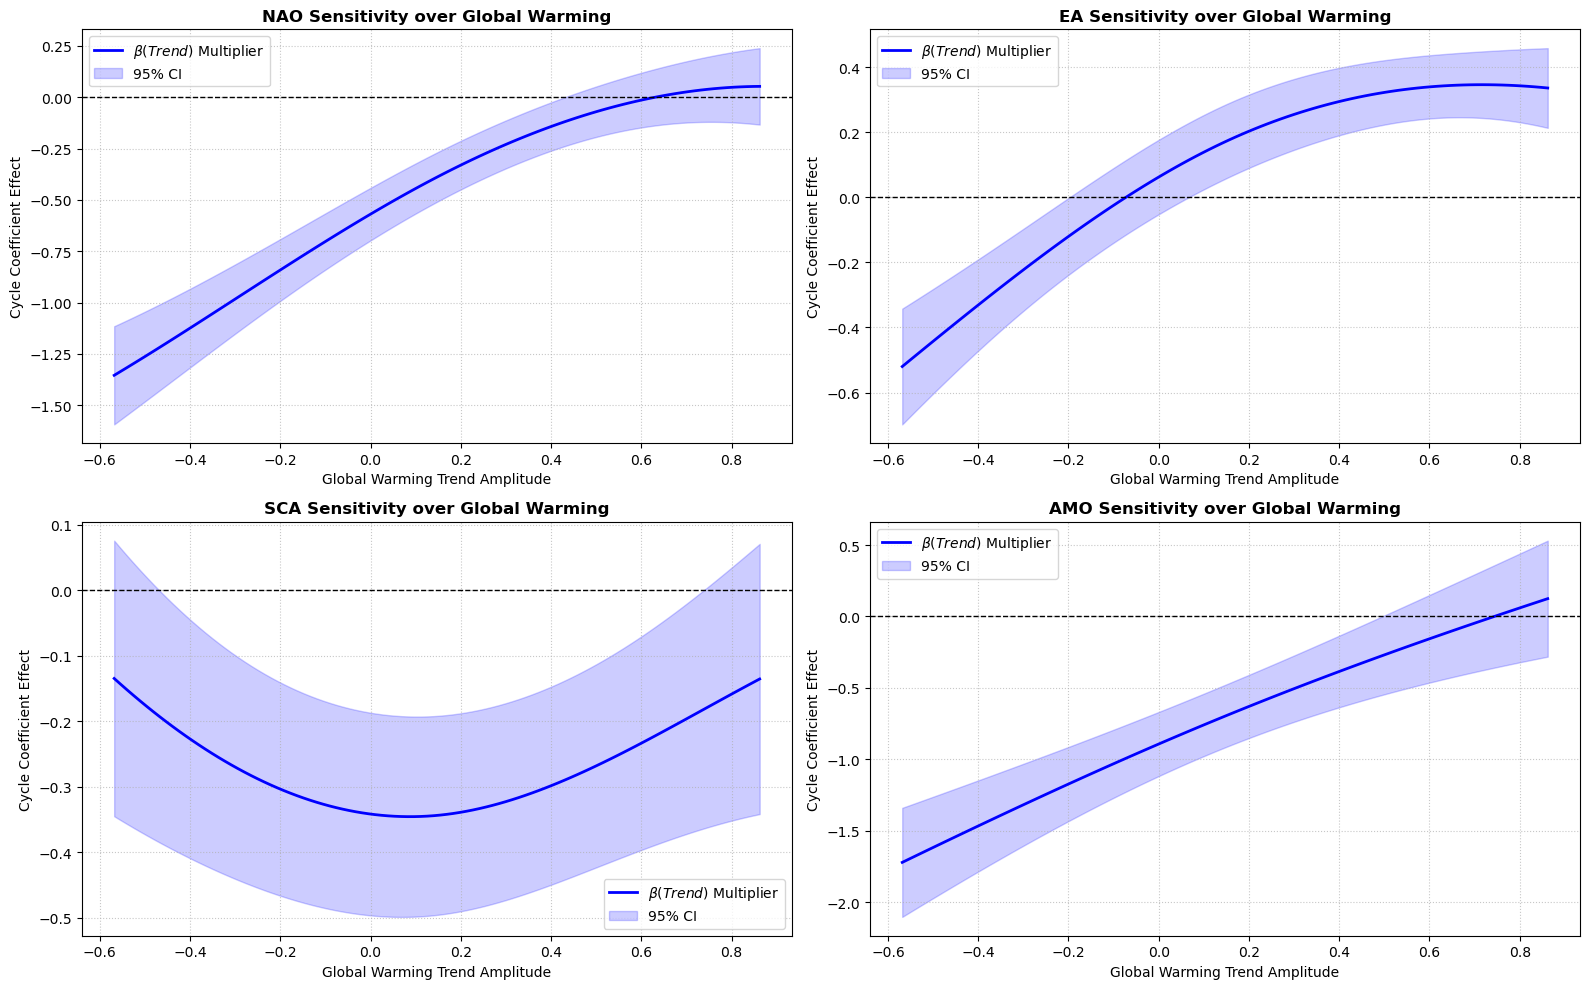

In [127]:
import matplotlib.pyplot as plt

# Define the exact term indices based on the architecture:
# l(0) [0], l(1) [1], l(2) [2], l(3) [3], s(4) [4]
# s(4, by=0) [5], s(4, by=1) [6], s(4, by=2) [7], s(4, by=3) [8]

interaction_terms = {
    'NAO Sensitivity': 5,
    'EA Sensitivity': 6,
    'SCA Sensitivity': 7,
    'AMO Sensitivity': 8
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (title, term_idx) in enumerate(interaction_terms.items()):
    ax = axes[idx]
    
    # Generate a dense grid strictly for the Trend variable (feature index 4)
    XX = best_model.generate_X_grid(term=term_idx)
    
    # Extract the partial dependence (the beta multiplier) and confidence intervals
    pdep, confi = best_model.partial_dependence(term=term_idx, X=XX, width=0.95)
    
    # XX[:, 4] isolates the Global Warming Trend values generated for the grid
    trend_grid = XX[:, 4]
    
    # Plotting
    ax.plot(trend_grid, pdep, color='blue', linewidth=2, label=r'$\beta(Trend)$ Multiplier')
    ax.fill_between(trend_grid, confi[:, 0], confi[:, 1], color='blue', alpha=0.2, label='95% CI')
    
    # Add a horizontal zero-line to identify phase inversions
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    
    ax.set_title(f'{title} over Global Warming', fontsize=12, fontweight='bold')
    ax.set_xlabel('Global Warming Trend Amplitude', fontsize=10)
    ax.set_ylabel(f'Cycle Coefficient Effect', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [107]:
import pandas as pd
from typing import List, Dict, Tuple

def engineer_time_series_features(
    df: pd.DataFrame, 
    lag_config: Dict[str, List[int]], 
    interaction_pairs: List[Tuple[str, str, str]]
) -> pd.DataFrame:
    """
    Expands a dataframe with specified lags and cross-feature interactions.
    
    Parameters:
    df (pd.DataFrame): Time-indexed dataframe.
    lag_config (Dict[str, List[int]]): Mapping of column names to lists of integer lags.
                                       e.g., {'price': [1, 2, 3], 'volume': [1, 5]}
    interaction_pairs (List[Tuple[str, str, str]]): List of tuples defining the interactions
                                                    (col_A, col_B, operation).
                                                    Valid operations: 'mul', 'add', 'div'.
    
    Returns:
    pd.DataFrame: DataFrame containing the original and newly engineered features.
    """
    df_expanded = df.copy()
    
    # 1. Generate Multiple Lags
    for feature, lags in lag_config.items():
        if feature not in df.columns:
            raise KeyError(f"Feature '{feature}' not found in DataFrame.")
            
        for lag in lags:
            lagged_col_name = f"{feature}_lag_{lag}"
            df_expanded[lagged_col_name] = df_expanded[feature].shift(lag)
            
    # 2. Generate Non-Independent Relations
    for col1, col2, op in interaction_pairs:
        if col1 not in df_expanded.columns or col2 not in df_expanded.columns:
            raise KeyError(f"Interaction features '{col1}' or '{col2}' not found.")
            
        interaction_name = f"{col1}_{op}_{col2}"
        
        if op == 'mul':
            df_expanded[interaction_name] = df_expanded[col1] * df_expanded[col2]
        elif op == 'add':
            df_expanded[interaction_name] = df_expanded[col1] + df_expanded[col2]
        elif op == 'div':
            # Replaces 0 with NaN to prevent ZeroDivisionError propagation into inf
            df_expanded[interaction_name] = df_expanded[col1] / df_expanded[col2].replace(0, pd.NA)
        else:
            raise ValueError(f"Unsupported operation: '{op}'")
            
    return df_expanded

# Example execution parameters:
# lag_config = {
#     'feature_A': [1, 2, 4],
#     'feature_B': [1, 12]
# }
# interaction_pairs = [
#     ('feature_A_lag_1', 'feature_B_lag_1', 'mul'), 
#     ('feature_A_lag_4', 'feature_A', 'div')       
# ]

In [98]:
import pandas as pd

# ==============================================================================
# 1. APPLYING THE TEMPORAL SHIFTS (LAGS)
# ==============================================================================
# We create a copy to avoid altering the original extracted cycles
df_predictive = df_gam_filtered.copy()

# The Atmospheric predictors operate concurrently (Lag 0), so we leave them alone.
# df_predictive['NAO_Cycle'] = df_gam_filtered['NAO_Cycle']
# df_predictive['EA_Cycle']  = df_gam_filtered['EA_Cycle']
# df_predictive['SCA_Cycle'] = df_gam_filtered['SCA_Cycle']

# The Oceanic predictor must be shifted FORWARD to align its past with the present target.
# A shift of +160 means the AMO value from row 0 is pushed down to row 160.


# ==============================================================================
# 2. MATRIX ALIGNMENT
# ==============================================================================
# Shifting arrays creates missing data (NaNs) at the beginning of the dataset.
# The first 160 months of the target variable no longer have a corresponding AMO history.
# We must drop these rows to ensure the GAM receives a complete, dense matrix.
df_predictive = df_predictive.dropna()

# ==============================================================================
# 3. DEFINING THE FINAL FEATURE TENSOR
# ==============================================================================
# Re-extract the aligned arrays
y_final = df_predictive['Temp_Cycle'].values

# The feature matrix X is now perfectly phase-aligned based on physical causality
X_final = df_predictive[['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle', 'Global_Warming']].values

In [99]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION (CONCURRENT STRICT)
# ==============================================================================
# IMPORTANT: Ensure X_final is an np.column_stack of all 5 arrays
X_concurrent = X_final
y_concurrent = y_final

# Index 0: NAO_Cycle (Concurrent)
# Index 1: EA_Cycle (Concurrent)
# Index 2: SCA_Cycle (Concurrent)
# Index 3: AMO_Cycle (Lagged or Concurrent based on your X_final construction)
# Index 4: Background_Trend (CEEMDAN Residual)

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
architectures = {
    # Baselines + Background Trend
    "1. Strictly Linear (Additive)": l(0) + l(1) + l(2) + l(3) + s(4, spline_order=2),
    "2. Independent Splines (Non-Linear Additive)": s(0, spline_order=2) + s(1, spline_order=2) + s(2, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # 2-Way Atmospheric Interactions + Independent Ocean + Background Trend
    "3. Interaction: [NAO x EA] + Splines(SCA, AMO)": te(0, 1, n_splines=(2, 2), spline_order=1) + s(2, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    "4. Interaction: [NAO x SCA] + Splines(EA, AMO)": te(0, 2, n_splines=(2, 2), spline_order=1) + s(1, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    "5. Interaction: [EA x SCA] + Splines(NAO, AMO)": te(1, 2, n_splines=(2, 2), spline_order=1) + s(0, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # 3-Way Atmospheric Tensors + Independent Ocean + Background Trend
    "6. 3-Way Atmospheric Tensor + Linear AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + l(3) + s(4, spline_order=2),
    "7. 3-Way Atmospheric Tensor + Spline AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # Fully Coupled 4-Dimensional Interaction + Background Trend
    "8. Full 4-Way Tensor (Atmosphere x Ocean)": te(0, 1, 2, 3, n_splines=(2, 2, 2, 2), spline_order=1) + s(4, spline_order=2)
    
}
architectures2 = {
    # -------------------------------------------------------------------------
    # CONTROL: The baseline we established (Trend is purely an additive intercept)
    "1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS A: The Trend only modulates the Ocean's heat release. 
    # The Atmosphere distributes it normally.
    "2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS B: The Trend modulates the Atmosphere INDIVIDUALLY.
    # The pressure networks are independent of each other, but dependent on the warming era.
    "3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]": 
        te(0, 4, n_splines=(3, 3), spline_order=2) + te(1, 4, n_splines=(3, 3), spline_order=2) + te(2, 4, n_splines=(3, 3), spline_order=2) + l(3),

    # -------------------------------------------------------------------------
    # HYPOTHESIS C: The Trend modulates the specific 2-Way atmospheric couplings.
    "4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)": 
        te(0, 1, 4, n_splines=(2, 2, 2), spline_order=1) + s(2, spline_order=2) + l(3),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS D: The Trend modulates the ENTIRE 3D atmospheric boundary layer.
    # The tri-pole behaves fundamentally differently in a hotter world.
    "5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean": 
        te(0, 1, 2, 4, n_splines=(2, 2, 2, 2), spline_order=1) + l(3),
        
    # -------------------------------------------------------------------------
    # HYPOTHESIS E: Total System Coupling (The absolute limit of PyGAM math).
    # Everything interacts with everything, shifting dynamically with global warming.
    "6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]": 
        te(0, 1, 2, 3, 4, n_splines=(2, 2, 2, 2, 2), spline_order=1)
}
# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS
# ==============================================================================
results = []

print(f"Executing Exhaustive Concurrent GAM Test on {len(X_concurrent)} rows with 5 Dimensions...")

for name, formulation in architectures2.items():
    try:
        model = LinearGAM(formulation)
        model.gridsearch(X_concurrent, y_concurrent, progress=False)
        
        results.append({
            "Architecture": name,
            "AIC": model.statistics_['AIC'],
            "GCV": model.statistics_['GCV'],
            "EDOF": model.statistics_['edof'],
            "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
        })
    except Exception as e:
        results.append({
            "Architecture": name,
            "AIC": float('inf'),
            "GCV": float('inf'),
            "EDOF": 0,
            "Pseudo R-Squared": 0.0
        })
        print(f"Failed on {name}: {e}")

# ==============================================================================
# 4. OUTPUT
# ==============================================================================
df_results = pd.DataFrame(results).sort_values(by="AIC")

print("\n========================================================================================")
print("ARCHITECTURE PERFORMANCE RANKING (ANCHORED TREND)")
print("========================================================================================")
print(df_results.to_string(index=False))

Executing Exhaustive Concurrent GAM Test on 905 rows with 5 Dimensions...

ARCHITECTURE PERFORMANCE RANKING (ANCHORED TREND)
                                                                Architecture          AIC      GCV      EDOF  Pseudo R-Squared
                   1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend -3916.796446 0.000795 32.473415          0.985105
                    6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend] -2011.096087 0.006525 31.999850          0.877537
3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend] -1756.819022 0.008532 18.981026          0.833004
                             2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere -1669.260027 0.009474 27.124123          0.819363
           5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean -1405.021393 0.012562 16.937372          0.752538
         4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO) -1195.462168 0.015962 25.239080     

In [87]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION
# ==============================================================================
# Index 0: NAO_Cycle 
# Index 1: EA_Cycle 
# Index 2: SCA_Cycle 
# Index 3: AMO_Lagged (160 Months)
# Index 4: Background_Trend (CEEMDAN Residual)

X_concurrent = X_final
y_concurrent = y_final

# ==============================================================================
# 2. TREND-DEPENDENT ARCHITECTURE DEFINITIONS
# ==============================================================================
architectures = {
    # -------------------------------------------------------------------------
    # CONTROL: The baseline we established (Trend is purely an additive intercept)
    "1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS A: The Trend only modulates the Ocean's heat release. 
    # The Atmosphere distributes it normally.
    "2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS B: The Trend modulates the Atmosphere INDIVIDUALLY.
    # The pressure networks are independent of each other, but dependent on the warming era.
    "3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]": 
        te(0, 4, n_splines=(3, 3), spline_order=2) + te(1, 4, n_splines=(3, 3), spline_order=2) + te(2, 4, n_splines=(3, 3), spline_order=2) + l(3),

    # -------------------------------------------------------------------------
    # HYPOTHESIS C: The Trend modulates the specific 2-Way atmospheric couplings.
    "4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)": 
        te(0, 1, 4, n_splines=(2, 2, 2), spline_order=1) + s(2, spline_order=2) + l(3),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS D: The Trend modulates the ENTIRE 3D atmospheric boundary layer.
    # The tri-pole behaves fundamentally differently in a hotter world.
    "5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean": 
        te(0, 1, 2, 4, n_splines=(2, 2, 2, 2), spline_order=1) + l(3),
        
    # -------------------------------------------------------------------------
    # HYPOTHESIS E: Total System Coupling (The absolute limit of PyGAM math).
    # Everything interacts with everything, shifting dynamically with global warming.
    "6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]": 
        te(0, 1, 2, 3, 4, n_splines=(2, 2, 2, 2, 2), spline_order=1)
}

# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS (Using 5-Fold Walk-Forward Validation)
# ==============================================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

print(f"Executing Walk-Forward Validation on Trend-Dependent Architectures...")

for name, formulation in architectures.items():
    print(f"Testing: {name}")
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_concurrent), 1):
        X_train, X_test = X_concurrent[train_index], X_concurrent[test_index]
        y_train, y_test = y_concurrent[train_index], y_concurrent[test_index]

        model = LinearGAM(formulation)
        
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': r2
            })
        except Exception as e:
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': np.nan
            })

df_folds = pd.DataFrame(fold_metrics)
df_summary = df_folds.groupby('Architecture')['R2'].mean().sort_values(ascending=False).reset_index()

print("\n===========================================================")
print("TREND-DEPENDENT OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)")
print("===========================================================")
print(df_summary.to_string(index=False))

Executing Walk-Forward Validation on Trend-Dependent Architectures...
Testing: 1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend
Testing: 2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere
Testing: 3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]
Testing: 4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)
Testing: 5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean
Testing: 6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]

TREND-DEPENDENT OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)
                                                                Architecture           R2
                             2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere   -99.752978
                   1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend  -103.352609
         4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)  -634.333999
3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]  -681.

In [73]:
np.mean(df_climate['EA'])

np.float64(-0.1309060773480663)

In [65]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION (CONCURRENT STRICT)
# ==============================================================================
# We use the clean, un-shifted CEEMDAN DataFrame.
# Drop any existing NaNs just to ensure matrix integrity.
df_concurrent = df_gam_filtered.dropna()

# Index 0: NAO_Cycle (Concurrent)
# Index 1: EA_Cycle (Concurrent)
# Index 2: SCA_Cycle (Concurrent)
# Index 3: AMO_Cycle (Concurrent)
X_concurrent = X_final
y_concurrent = y_final

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
# We constrain the tensors (n_splines) to prevent the EDOF from exploding past 30-40,
# ensuring we test general physics rather than overfitting the exact time series.

architectures = {
    # Baselines
    "1. Strictly Linear (Additive)": l(0) + l(1) + l(2) + l(3),
    "2. Independent Splines (Non-Linear Additive)": s(0, spline_order=2) + s(1, spline_order=2) + s(2, spline_order=2) + s(3, spline_order=2),
    
    # 2-Way Atmospheric Interactions + Independent Ocean
    "3. Interaction: [NAO x EA] + Splines(SCA, AMO)": te(0, 1, n_splines=(2, 2), spline_order=1) + s(2, spline_order=2) + s(3, spline_order=2),
    "4. Interaction: [NAO x SCA] + Splines(EA, AMO)": te(0, 2, n_splines=(2, 2), spline_order=1) + s(1, spline_order=2) + s(3, spline_order=2),
    "5. Interaction: [EA x SCA] + Splines(NAO, AMO)": te(1, 2, n_splines=(2, 2), spline_order=1) + s(0, spline_order=2) + s(3, spline_order=2),
    
    # 3-Way Atmospheric Tensors + Independent Ocean
    "6. 3-Way Atmospheric Tensor + Linear AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + l(3),
    "7. 3-Way Atmospheric Tensor + Spline AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + s(3, spline_order=2),
    
    # Fully Coupled 4-Dimensional Interaction (Highly Constrained)
    "8. Full 4-Way Tensor (Atmosphere x Ocean)": te(0, 1, 2, 3, n_splines=(2, 2, 2, 2), spline_order=1)
}

# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS
# ==============================================================================
results = []

print(f"Executing Exhaustive Concurrent GAM Test on {len(X_concurrent)} rows...")

for name, formulation in architectures.items():
    try:
        model = LinearGAM(formulation)
        model.gridsearch(X_concurrent, y_concurrent, progress=False)
        
        results.append({
            "Architecture": name,
            "AIC": model.statistics_['AIC'],
            "GCV": model.statistics_['GCV'],
            "EDOF": model.statistics_['edof'],
            "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
        })
    except Exception as e:
        # Failsafe in case a specific tensor constraint collapses the solver
        results.append({
            "Architecture": name,
            "AIC": float('inf'),
            "GCV": float('inf'),
            "EDOF": 0,
            "Pseudo R-Squared": 0.0
        })
        print(f"Failed on {name}: {e}")

# ==============================================================================
# 4. OUTPUT
# ==============================================================================
df_results = pd.DataFrame(results).sort_values(by="AIC")

print("\n========================================================================================")
print("CONCURRENT ARCHITECTURE PERFORMANCE RANKING")
print("========================================================================================")
print(df_results.to_string(index=False))

Executing Exhaustive Concurrent GAM Test on 905 rows...

CONCURRENT ARCHITECTURE PERFORMANCE RANKING
                                  Architecture          AIC      GCV      EDOF  Pseudo R-Squared
  2. Independent Splines (Non-Linear Additive) -1271.379780 0.015454 73.110053          0.974307
3. Interaction: [NAO x EA] + Splines(SCA, AMO)  -234.512228 0.046741 37.796608          0.912422
4. Interaction: [NAO x SCA] + Splines(EA, AMO)  -106.794250 0.053829 37.869704          0.899164
5. Interaction: [EA x SCA] + Splines(NAO, AMO)   -45.846239 0.057396 34.760827          0.891380
      7. 3-Way Atmospheric Tensor + Spline AMO   134.094628 0.069367 25.331188          0.864648
     8. Full 4-Way Tensor (Atmosphere x Ocean)   281.374012 0.080898 15.999994          0.837369
      6. 3-Way Atmospheric Tensor + Linear AMO   590.210778 0.113061  8.994277          0.767630
                 1. Strictly Linear (Additive)   602.199312 0.114144  4.908828          0.762388


Training Observations: 724
Testing Observations:  181

--- OUT-OF-SAMPLE DIAGNOSTICS ---
Out-of-Sample R-Squared: -15.2317
Out-of-Sample MSE:       1.5240


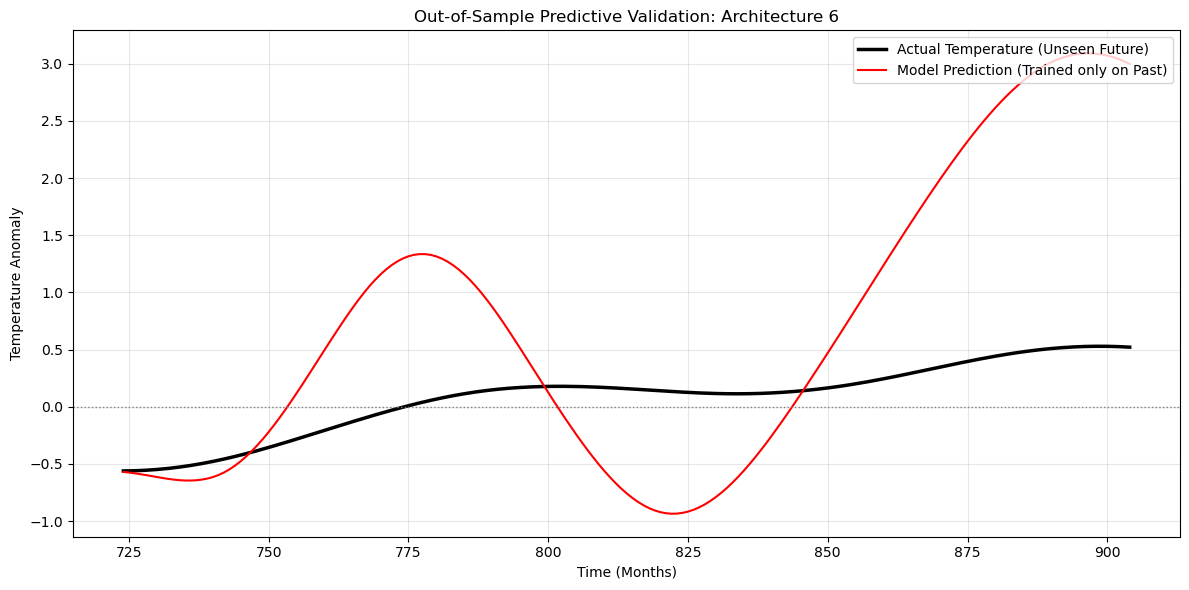

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, te, l
from sklearn.metrics import r2_score, mean_squared_error

# ==============================================================================
# 1. TIME-SERIES CHRONOLOGICAL SPLIT (80% Train / 20% Test)
# ==============================================================================
# We CANNOT use random cross-validation on time series due to autocorrelation.
# We must split chronologically.

split_index = int(len(X_concurrent) * 0.80)

# Training Data (The Past: e.g., 1950 to ~2010)
X_train = X_concurrent[:split_index]
y_train = y_concurrent[:split_index]

# Testing Data (The Future: e.g., ~2010 to 2025)
X_test = X_concurrent[split_index:]
y_test = y_concurrent[split_index:]

print(f"Training Observations: {len(X_train)}")
print(f"Testing Observations:  {len(X_test)}")

# ==============================================================================
# 2. ISOLATED TRAINING
# ==============================================================================
# Fit Architecture 6 STRICTLY on the training subset
validation_model = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2))
validation_model.gridsearch(X_train, y_train, progress=False)

# ==============================================================================
# 3. BLIND PREDICTION & METRICS
# ==============================================================================
# Force the model to predict the test set (which it has never seen)
y_pred_test = validation_model.predict(X_test)

# Calculate Out-of-Sample R-Squared and MSE
# Using sklearn's r2_score for standard out-of-sample evaluation
out_of_sample_r2 = r2_score(y_test, y_pred_test)
out_of_sample_mse = mean_squared_error(y_test, y_pred_test)

print(f"\n--- OUT-OF-SAMPLE DIAGNOSTICS ---")
print(f"Out-of-Sample R-Squared: {out_of_sample_r2:.4f}")
print(f"Out-of-Sample MSE:       {out_of_sample_mse:.4f}")

# ==============================================================================
# 4. VISUAL VALIDATION
# ==============================================================================
plt.figure(figsize=(12, 6))

# Create a continuous time axis for plotting
time_test = np.arange(split_index, len(y_concurrent))

plt.plot(time_test, y_test, color='black', linewidth=2.5, label='Actual Temperature (Unseen Future)')
plt.plot(time_test, y_pred_test, color='red', linewidth=1.5, label='Model Prediction (Trained only on Past)')

plt.title('Out-of-Sample Predictive Validation: Architecture 6')
plt.xlabel('Time (Months)')
plt.ylabel('Temperature Anomaly')
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd
from pygam import LinearGAM

# Define the number of folds (5 folds for decadal data)
tscv = TimeSeriesSplit(n_splits=5)

fold_metrics = []

# CORRECT UNPACKING: Separate the string name from the PyGAM formulation
for name, formulation in architectures.items():
    print(f"Testing Architecture: {name}...")
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_final), 1):
        # Split the data chronologically
        X_train, X_test = X_final[train_index], X_final[test_index]
        y_train, y_test = y_final[train_index], y_final[test_index]

        # Instantiate the model with the isolated TermList
        model = LinearGAM(formulation)
        
        try:
            # Fit and Predict
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Calculate Metrics
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': r2,
                'MSE': mse
            })
        except Exception as e:
            # PyGAM splines can occasionally fail to fit on the very first 
            # fold if the training sample is too small. We catch that here.
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': np.nan,
                'MSE': np.nan
            })

# Compile the raw fold data
df_folds = pd.DataFrame(fold_metrics)

# Calculate the mean Out-of-Sample R2 across all 5 folds to find the definitive winner
df_summary = df_folds.groupby('Architecture')['R2'].mean().sort_values(ascending=False).reset_index()

print("\n===========================================================")
print("CROSS-VALIDATED OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)")
print("===========================================================")
print(df_summary.to_string(index=False))

Testing Architecture: 1. Strictly Linear (Additive)...
Testing Architecture: 2. Independent Splines (Non-Linear Additive)...
Testing Architecture: 3. Interaction: [NAO x EA] + Splines(SCA, AMO)...
Testing Architecture: 4. Interaction: [NAO x SCA] + Splines(EA, AMO)...
Testing Architecture: 5. Interaction: [EA x SCA] + Splines(NAO, AMO)...
Testing Architecture: 6. 3-Way Atmospheric Tensor + Linear AMO...
Testing Architecture: 7. 3-Way Atmospheric Tensor + Spline AMO...
Testing Architecture: 8. Full 4-Way Tensor (Atmosphere x Ocean)...

CROSS-VALIDATED OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)
                                  Architecture           R2
                 1. Strictly Linear (Additive)   -73.905687
4. Interaction: [NAO x SCA] + Splines(EA, AMO)  -517.951555
5. Interaction: [EA x SCA] + Splines(NAO, AMO)  -535.942926
      6. 3-Way Atmospheric Tensor + Linear AMO  -750.596363
  2. Independent Splines (Non-Linear Additive)  -919.530952
3. Interaction: [NAO x EA] + Splines(SCA,

Historical Epoch R-Squared: 0.7185


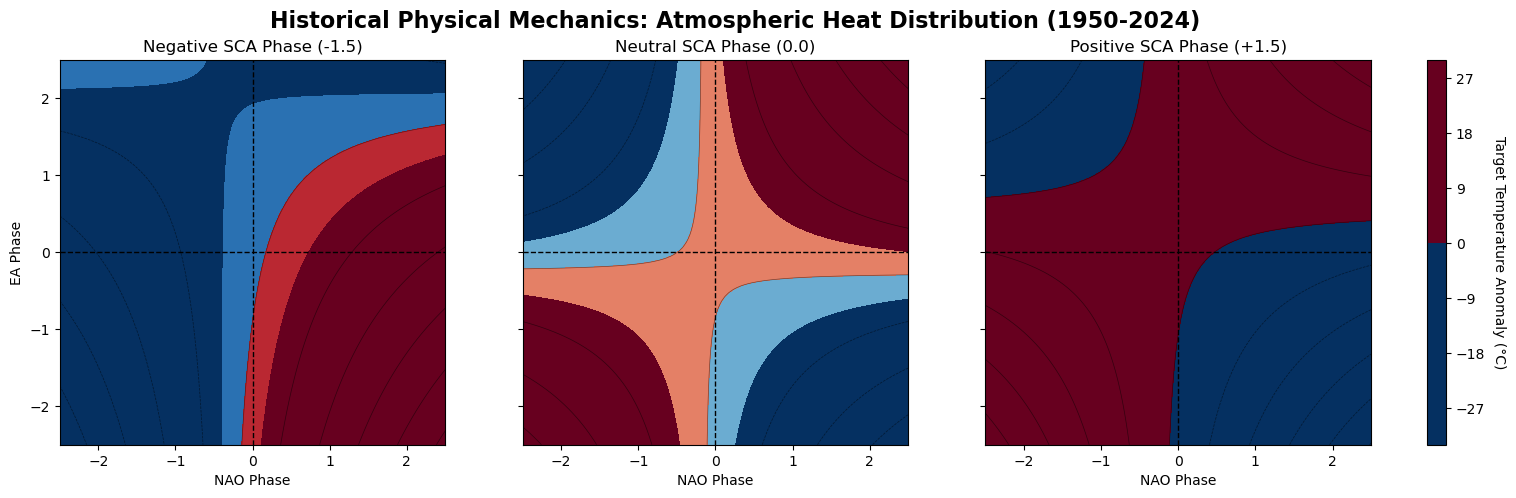

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, te, l, s

# ==============================================================================
# 1. FIT THE EPOCHAL MODEL (1950 - 2024)
# ==============================================================================
# We use the full matrix to map the complete historical epoch.
# Index 0: NAO, 1: EA, 2: SCA, 3: AMO_Lagged, 4: Background_Trend
model = LinearGAM(
    te(0, 1, 2, n_splines=(4, 4, 4)) + l(3) + s(4, spline_order=2)
)
model.fit(X_final, y_final)

print(f"Historical Epoch R-Squared: {model.statistics_['pseudo_r2']['explained_deviance']:.4f}")

# ==============================================================================
# 2. SYNTHESIZE THE PHASE SPACE
# ==============================================================================
# To visualize a 3D interaction (NAO x EA x SCA), we must look at 2D slices.
# We will create a grid of NAO and EA combinations, and view them under 
# three different "regimes" of the Scandinavian Blocking pattern (SCA).

# Define the grid boundaries (typically -2.5 to +2.5 standard deviations)
nao_range = np.linspace(-2.5, 2.5, 100)
ea_range = np.linspace(-2.5, 2.5, 100)

# Create the 2D meshgrid
NAO_grid, EA_grid = np.meshgrid(nao_range, ea_range)

# Flatten the grids for PyGAM prediction
NAO_flat = NAO_grid.flatten()
EA_flat = EA_grid.flatten()

# Freeze the slow-moving baselines at zero (neutral ocean, neutral trend)
# This isolates the pure atmospheric physics.
AMO_neutral = np.zeros_like(NAO_flat)
Trend_neutral = np.zeros_like(NAO_flat)

# Define the three SCA phases to test
sca_phases = {
    "Negative SCA Phase (-1.5)": -1.5,
    "Neutral SCA Phase (0.0)": 0.0,
    "Positive SCA Phase (+1.5)": 1.5
}

# ==============================================================================
# 3. VISUALIZE THE THERMODYNAMIC MECHANICS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Historical Physical Mechanics: Atmospheric Heat Distribution (1950-2024)', fontsize=16, fontweight='bold')

for ax, (title, sca_val) in zip(axes, sca_phases.items()):
    
    # Create the SCA array for this specific slice
    SCA_flat = np.full_like(NAO_flat, sca_val)
    
    # Assemble the synthetic feature matrix
    X_synthetic = np.column_stack((NAO_flat, EA_flat, SCA_flat, AMO_neutral, Trend_neutral))
    
    # Predict the thermal anomaly for this specific grid
    Temp_pred = model.predict(X_synthetic)
    
    # Reshape back to 2D for contour plotting
    Temp_grid = Temp_pred.reshape(100, 100)
    
    # Plot the heat map (Contour)
    contour = ax.contourf(NAO_grid, EA_grid, Temp_grid, levels=20, cmap='RdBu_r', vmin=-1.0, vmax=1.0)
    ax.contour(NAO_grid, EA_grid, Temp_grid, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    
    ax.set_title(title)
    ax.set_xlabel('NAO Phase')
    if ax == axes[0]:
        ax.set_ylabel('EA Phase')
    
    # Add crosshairs for the neutral (0,0) center
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

# Add a shared colorbar
cbar = fig.colorbar(contour, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
cbar.set_label('Target Temperature Anomaly (°C)', rotation=270, labelpad=15)

plt.show()

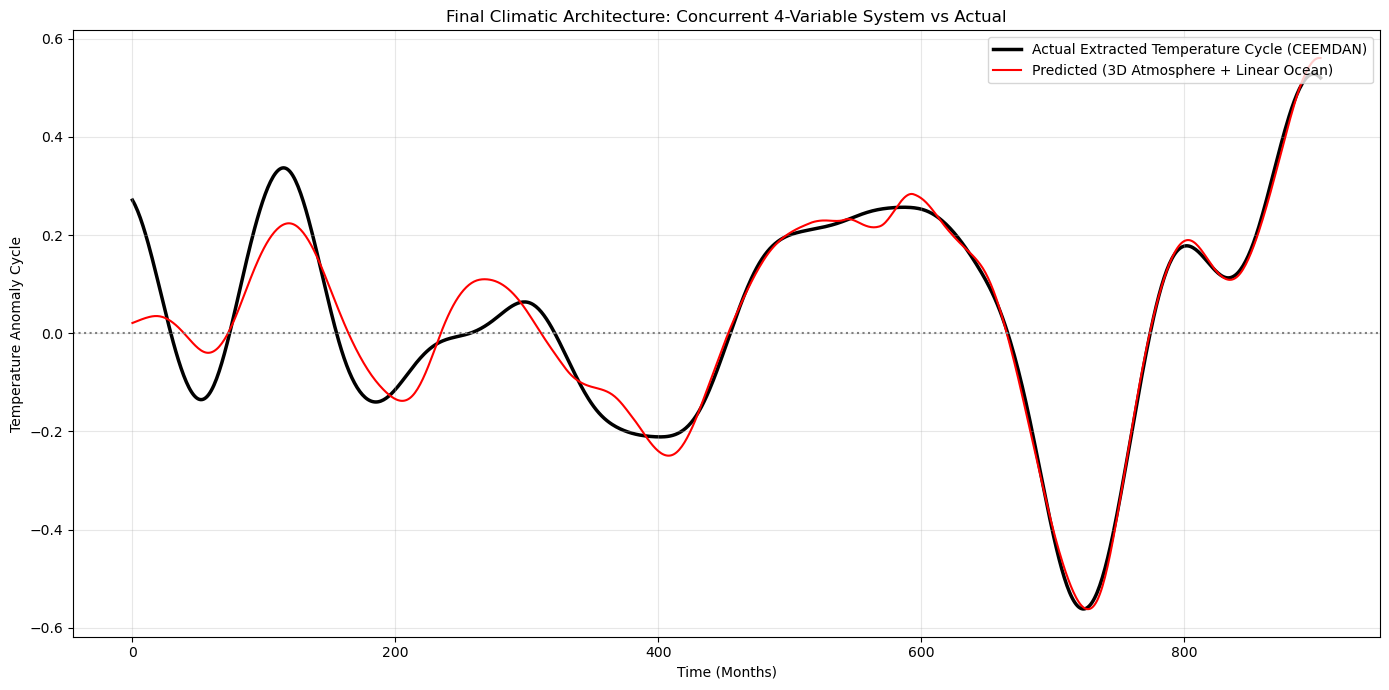

Final Model Mean Squared Error: 0.0024


In [102]:
import matplotlib.pyplot as plt

# Instantiate and fit the optimal architecture
# Index 0: NAO, Index 1: EA, Index 2: SCA, Index 3: AMO
final_concurrent_model = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2))
final_concurrent_model.fit(X_concurrent, y_concurrent)

# Generate predictions
y_pred_final = final_concurrent_model.predict(X_concurrent)

# Plot the Final Verification
plt.figure(figsize=(14, 7))

plt.plot(y_concurrent, color='black', linewidth=2.5, label='Actual Extracted Temperature Cycle (CEEMDAN)', zorder=1)
plt.plot(y_pred_final, color='red', linewidth=1.5, label='Predicted (3D Atmosphere + Linear Ocean)', zorder=2)

plt.title('Final Climatic Architecture: Concurrent 4-Variable System vs Actual')
plt.xlabel('Time (Months)')
plt.ylabel('Temperature Anomaly Cycle')
plt.axhline(0, color='gray', linestyle=':', linewidth=1.5)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final Error Metric
mse_final = np.nanmean((y_concurrent - y_pred_final)**2)
print(f"Final Model Mean Squared Error: {mse_final:.4f}")

In [120]:
df_gam_filtered= df_gam_filtered.drop(columns="test")

In [108]:
df_gam_filtered['AMO_Cycle']

Date
1950-01-01   -0.03
1950-02-01   -0.13
1950-03-01   -0.16
1950-04-01   -0.22
1950-05-01   -0.23
              ... 
2025-01-01    0.98
2025-02-01    0.86
2025-03-01    0.75
2025-04-01    0.67
2025-05-01    0.73
Name: AMO_Cycle, Length: 905, dtype: float64

In [96]:
df_amo[2]

0     -0.03
1     -0.13
2     -0.16
3     -0.22
4     -0.23
       ... 
907    0.83
908    0.76
909    1.01
910    0.96
911    0.75
Name: 2, Length: 912, dtype: float64

In [21]:
from pygam import LinearGAM, te, l, s

# We force a low-resolution tensor grid. 
# n_splines=(5, 5, 5) limits the basis functions for each dimension.
architectures_constrained = {
    # The unrestricted winner (for direct baseline comparison)
    "Unrestricted 3-Way Tensor": te(0, 1, 2),
    
    # Constrained 3-Way Tensors
    "Constrained 3-Way (5 nodes)": te(0, 1, 2, n_splines=(5, 5, 5)),
    "Constrained 3-Way (4 nodes)": te(0, 1, 2, n_splines=(4, 4, 4)),
    
    # Constrained 2-Way Tensors with Linear Baseline
    "Constrained 2-Way (NAO & EA) + Linear Lag": te(0, 2, n_splines=(6, 6)) + l(1),
    
    # The purely linear baseline (to ensure the restricted tensors still outperform it)
    "Linear Baseline": l(0) + l(1) + l(2)
}

results_constrained = []

for name, formulation in architectures_constrained.items():
    model = LinearGAM(formulation)
    model.gridsearch(X, y, progress=False)
    
    results_constrained.append({
        "Architecture": name,
        "AIC": model.statistics_['AIC'],
        "GCV": model.statistics_['GCV'],
        "EDOF": model.statistics_['edof'],
        "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
    })

df_constrained = pd.DataFrame(results_constrained).sort_values(by="AIC")
print(df_constrained.to_string(index=False))

                             Architecture        AIC      GCV       EDOF  Pseudo R-Squared
                Unrestricted 3-Way Tensor 332.267466 0.104665 114.786017          0.612492
              Constrained 3-Way (5 nodes) 592.798317 0.129320  29.064896          0.316594
              Constrained 3-Way (4 nodes) 647.036489 0.136445  14.894419          0.239557
Constrained 2-Way (NAO & EA) + Linear Lag 647.414753 0.137710  22.669170          0.254446
                          Linear Baseline 725.709803 0.149218   3.960025          0.134358


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Instantiate and fit the winning architecture
# Index 0: NAO, Index 1: NAO_Lag135, Index 2: EA
final_gam = LinearGAM(te(0, 2) + l(1))
final_gam.gridsearch(X, y, progress=False)

# Generate a 2D grid for the tensor term (term=0 corresponds to te(0, 2))
# This creates a meshgrid of the NAO (feature 0) and EA (feature 2)
XX = final_gam.generate_X_grid(term=0, n=100)

# Calculate the partial dependence (the isolated temperature impact)
Z = final_gam.partial_dependence(term=0, X=XX)

# Reshape the output for contour plotting
x_nao = XX[:, 0].reshape(100, 100)
y_ea = XX[:, 2].reshape(100, 100)
z_temp = Z.reshape(100, 100)

# Plot the Interaction Surface
plt.figure(figsize=(10, 8))
contour = plt.contourf(x_nao, y_ea, z_temp, levels=50, cmap='coolwarm')
plt.colorbar(contour, label='Partial Dependence: Target Temperature Impact')

# Formatting
plt.title('NAO & EA Coupled Interaction Manifold')
plt.xlabel('North Atlantic Oscillation (NAO) Z-Score')
plt.ylabel('East Atlantic Pattern (EA) Z-Score')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# Output the coefficient for the strictly linear 135-month gyre lag (term 1)
gyre_coef = final_gam.coef_[-2] # Second to last coefficient is the linear term, last is intercept
print(f"Linear Gyre Forcing Coefficient (Lag 135): {gyre_coef:.5f}")

ValueError: term requires feature 2, but X has only 2 dimensions

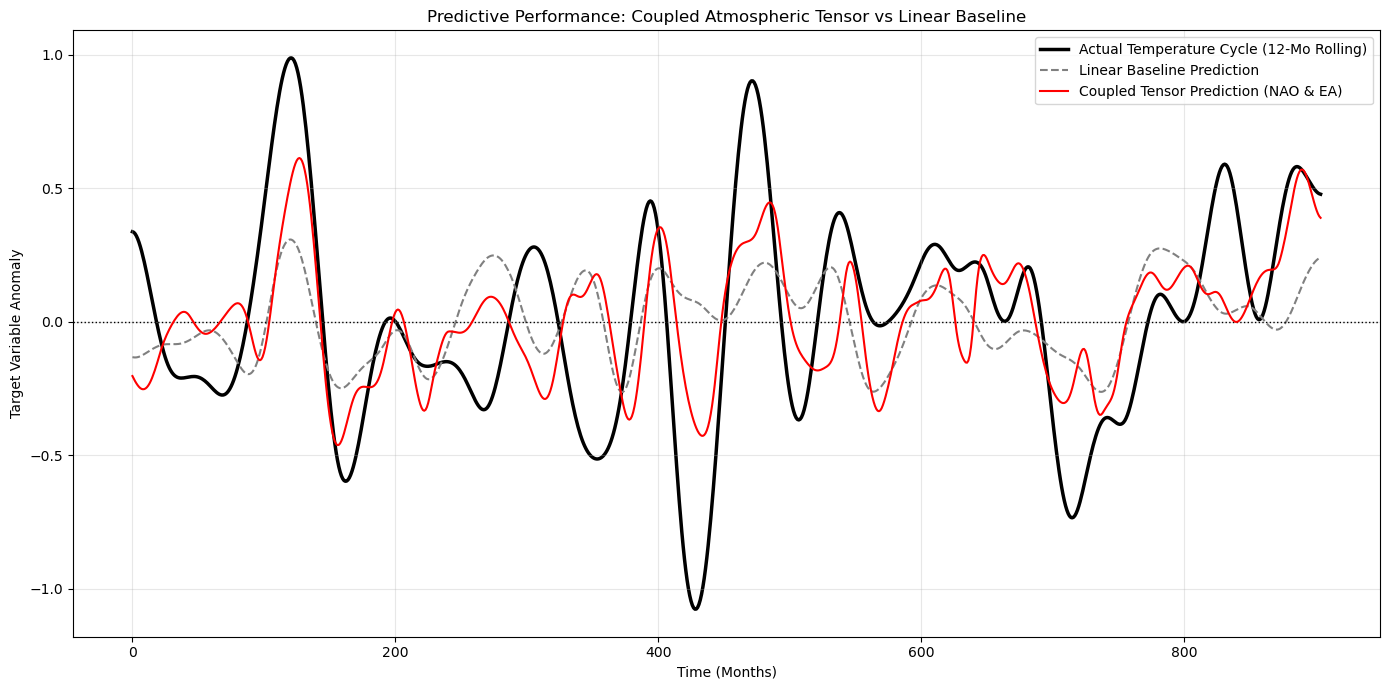

MSE (Linear Baseline vs Cycle): 0.1290
MSE (Tensor Model vs Cycle):    0.0903


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, l, te

# ==============================================================================
# 1. MODEL INSTANTIATION AND PREDICTION
# ==============================================================================
# Ensure your feature matrix X (NAO, NAO_Lag135, EA) and target y are loaded.
# Re-instantiate and fit the two competing models
X= X_final
y= y_final
model_linear = LinearGAM(l(0) + l(1) + l(2))
model_linear.fit(X, y)

model_tensor = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2))
model_tensor.fit(X, y)

# Generate the predicted arrays
y_pred_linear = model_linear.predict(X)
y_pred_tensor = model_tensor.predict(X)

# ==============================================================================
# 2. ISOLATING THE TARGET CYCLE
# ==============================================================================
# To plot "against the cycles", we calculate a 12-month moving average of the 
# actual temperature to filter out high-frequency noise and reveal the base cycle.
# (Alternatively, you can replace 'y_cycle' directly with your CEEMDAN IMF 5 array)
y_series = pd.Series(y)
y_cycle = y

# ==============================================================================
# 3. PLOTTING THE COMPARISON
# ==============================================================================
# Create a time array (assuming monthly data, length matches y)
time_axis = np.arange(len(y))

plt.figure(figsize=(14, 7))

# Plot 1: The underlying physical cycle (Smoothed Actuals or IMF)
plt.plot(time_axis, y_cycle, color='black', linewidth=2.5, label='Actual Temperature Cycle (12-Mo Rolling)', zorder=1)

# Plot 2: The Linear Baseline Prediction
plt.plot(time_axis, y_pred_linear, color='gray', linestyle='--', linewidth=1.5, label='Linear Baseline Prediction', zorder=2)

# Plot 3: The Tensor Interaction Prediction
plt.plot(time_axis, y_pred_tensor, color='red', linewidth=1.5, label='Coupled Tensor Prediction (NAO & EA)', zorder=3)

# Formatting the plot
plt.title('Predictive Performance: Coupled Atmospheric Tensor vs Linear Baseline')
plt.xlabel('Time (Months)')
plt.ylabel('Target Variable Anomaly')
plt.axhline(0, color='black', linestyle=':', linewidth=1)

# Optional: Zoom in on a specific 20-year window to see the exact divergence
# plt.xlim(200, 440) 

plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. RESIDUAL CALCULATION (Optional Diagnostic)
# ==============================================================================
# Calculate the Mean Squared Error against the cycle to quantify the visual gap
mse_linear = np.nanmean((y_cycle - y_pred_linear)**2)
mse_tensor = np.nanmean((y_cycle - y_pred_tensor)**2)

print(f"MSE (Linear Baseline vs Cycle): {mse_linear:.4f}")
print(f"MSE (Tensor Model vs Cycle):    {mse_tensor:.4f}")